In [2]:
import pandas as pd

In [241]:
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load your training data
df_features = pd.read_csv('dataset_7.csv')
df_targets = pd.read_csv('target_7.csv')

depth= 6

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(df_features, df_targets['target02'], test_size=0.5, random_state=42)

# Initialize and train the  Decision Tree model
Tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
Tree.fit(X_train, y_train)


# Make predictions
y_pred= Tree.predict(X_test)



In [242]:

r2_train = r2_score(y_train, Tree.predict(X_train))
print(f"R-squared (R2) Train: {r2_train}")
rmse_train = np.sqrt(mean_squared_error(y_train, Tree.predict(X_train)))
print(f"Root Mean Squared Error (RMSE) Train: {rmse_train}")


r2_test = r2_score(y_test, y_pred)
print(f"R-squared (R2) Test: {r2_test}")
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Squared Error (RMSE) Test: {rmse_test}")



R-squared (R2) Train: 0.9701159164463107
Root Mean Squared Error (RMSE) Train: 0.13213528863358825
R-squared (R2) Test: 0.9580555864000407
Root Mean Squared Error (RMSE) Test: 0.15448486917922521


In [81]:
# X.corr()
# y.c/orr()
y.describe()

count    10000.000000
mean         0.202261
std          0.236720
min         -0.228830
25%          0.017569
50%          0.099274
75%          0.407457
max          0.891699
Name: target01, dtype: float64

Dataset Loaded: 10000 rows, 273 features


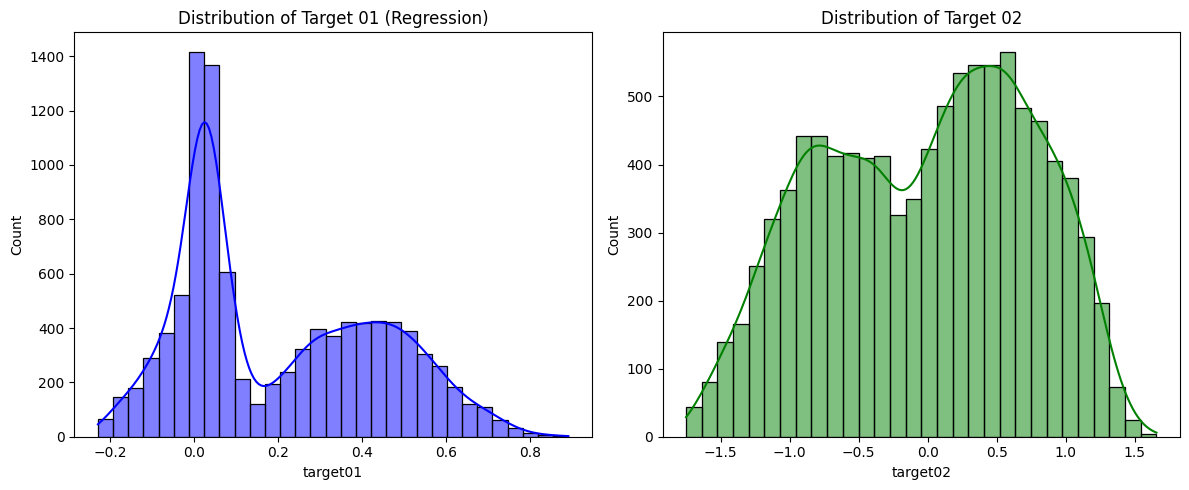

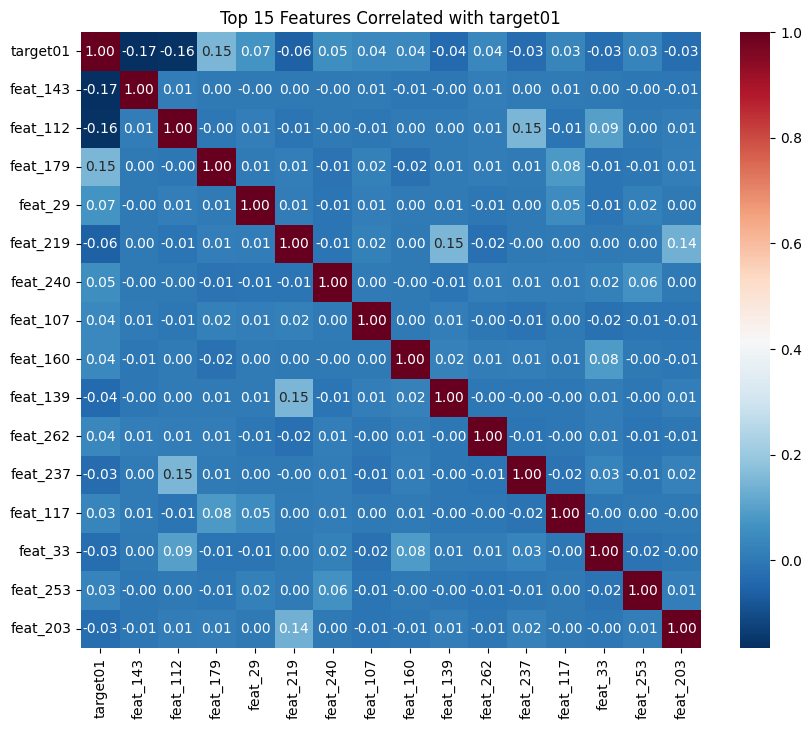

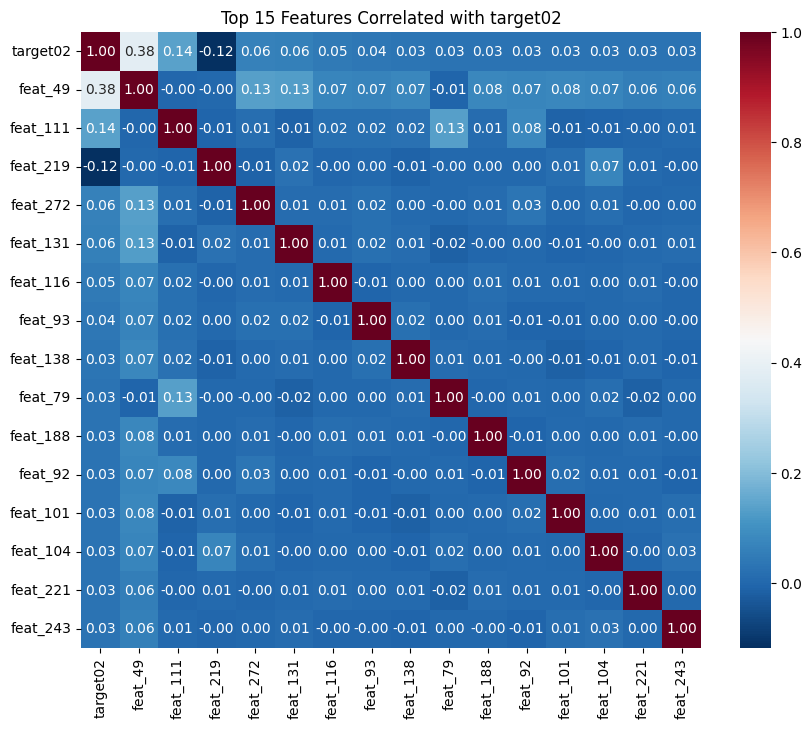

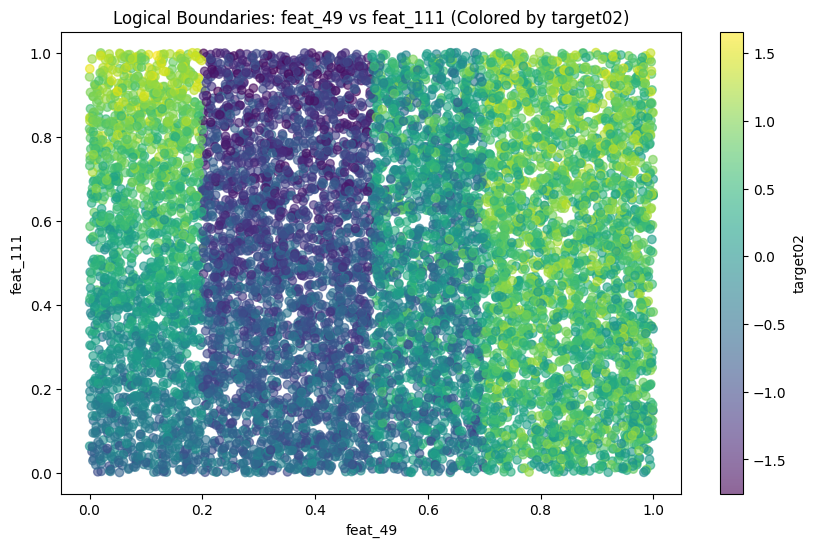

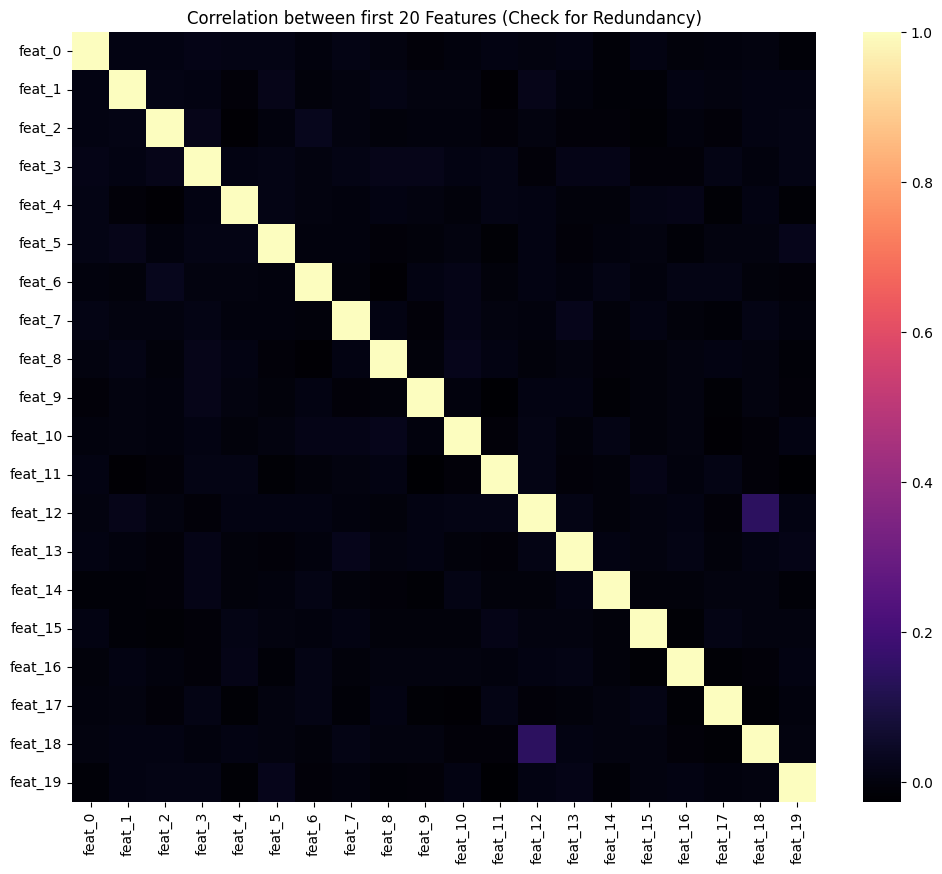

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD DATA
# Ensure your filenames match your ID (7)
df_features = pd.read_csv('dataset_7.csv')
df_targets = pd.read_csv('target_7.csv')

# Merge for correlation analysis
df_full = pd.concat([df_features, df_targets], axis=1)

print(f"Dataset Loaded: {df_features.shape[0]} rows, {df_features.shape[1]} features")

# --- PART 1: TARGET ANALYSIS ---
def analyze_targets(targets):
    plt.figure(figsize=(12, 5))
    
    # Target 01 Distribution (Continuous)
    plt.subplot(1, 2, 1)
    sns.histplot(targets['target01'], kde=True, color='blue')
    plt.title('Distribution of Target 01 (Regression)')
    
    # Target 02 Distribution (Rule-based/Logic)
    plt.subplot(1, 2, 2)
    sns.histplot(targets['target02'], kde=True, color='green')
    plt.title('Distribution of Target 02')
    
    plt.tight_layout()
    plt.show()

analyze_targets(df_targets)

# --- PART 2: FEATURE-TARGET CORRELATION (The "Discovery" Phase) ---
def plot_top_correlations(df, target_col, n=15):
    # Calculate correlations
    corr_matrix = df.corr()
    # Get absolute correlations with the specific target
    top_corr = corr_matrix[target_col].abs().sort_values(ascending=False).head(n+1)
    top_features = top_corr.index
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(df[top_features].corr(), annot=True, cmap='RdBu_r', fmt=".2f")
    plt.title(f'Top {n} Features Correlated with {target_col}')
    plt.show()
    return top_features

# Run for both targets
top_feats_t1 = plot_top_correlations(df_full, 'target01')
top_feats_t2 = plot_top_correlations(df_full, 'target02')

# --- PART 3: RULE DISCOVERY VISUALS (For Target 02) ---
def rule_discovery_plot(df, top_features, target_col):
    # We take the top 2 features correlated with Target 02
    # and plot them to see if there is a geometric/logical boundary
    f1 = top_features[1] # [0] is the target itself
    f2 = top_features[2]
    
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(df[f1], df[f2], c=df[target_col], cmap='viridis', alpha=0.6)
    plt.colorbar(scatter, label=target_col)
    plt.xlabel(f1)
    plt.ylabel(f2)
    plt.title(f'Logical Boundaries: {f1} vs {f2} (Colored by {target_col})')
    plt.show()

rule_discovery_plot(df_full, top_feats_t2, 'target02')

# --- PART 4: FEATURE REDUNDANCY (Feature vs Feature) ---
def internal_feature_correlation(df, n_sample=20):
    # Sampling the first 20 features just to see if the data is redundant/sparse
    subset = df.iloc[:, :n_sample]
    plt.figure(figsize=(12, 10))
    sns.heatmap(subset.corr(), cmap='magma')
    plt.title('Correlation between first 20 Features (Check for Redundancy)')
    plt.show()

internal_feature_correlation(df_features)

#AGain But now With Evaluation

In [190]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(df_features, df_targets['target02'], test_size=0.5, random_state=42)

# Initialize and train the model
rf = RandomForestRegressor(n_estimators=5, max_depth=8, random_state=42)
rf.fit(X_train, y_train)

# Make predictions
y_pred = rf.predict(X_test)


In [193]:
# Create a Series to see which features the model actually uses
importances = pd.Series(rf.feature_importances_, index=df_features.columns)
print(importances.sort_values(ascending=False).head(10))

feat_49     0.707358
feat_219    0.142782
feat_111    0.121745
feat_22     0.025396
feat_65     0.000148
feat_129    0.000127
feat_23     0.000097
feat_245    0.000093
feat_120    0.000056
feat_170    0.000054
dtype: float64


In [ ]:
mae_train = mean_absolute_error(y_train, rf.predict(X_train))
print(f"Mean Absolute Error (MAE) Train: {mae_train}")
mae_test = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE) Test: {mae_test}")

mse_train = mean_squared_error(y_train, rf.predict(X_train))
print(f"Mean Squared Error (MSE) Train: {mse_train}")
mse_test = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE) Test: {mse_test}")

r2_train = r2_score(y_train, rf.predict(X_train))
print(f"R-squared (R2) Train: {r2_train}")
r2_test = r2_score(y_test, y_pred)
print(f"R-squared (R2) Test: {r2_test}")

gap_percent_r2= 100 * (r2_train - r2_test) / r2_train if r2_train != 0 else None
print(f"Gap Percent of R2: {gap_percent_r2}")

Mean Absolute Error (MAE) Train: 0.044819093636524046
Mean Absolute Error (MAE) Test: 0.06154409926982435
Mean Squared Error (MSE) Train: 0.003757410707032935
Mean Squared Error (MSE) Test: 0.008282874857390075
R-squared (R2) Train: 0.9935688154078274
R-squared (R2) Test: 0.9854426163354928
Gap Percent of R2: 0.8178798434811025


In [203]:
from sklearn.feature_selection import mutual_info_regression

# Calculate MI for target01
df_features = pd.read_csv('dataset_7.csv')
df_targets = pd.read_csv('target_7.csv')

X_train, X_test, y_train, y_test = train_test_split(
    df_features, df_targets['target02'], test_size=0.5, random_state=42
)

mi_scores = mutual_info_regression(X_train, y_train)
mi_series = pd.Series(mi_scores, index=df_features.columns)
print(mi_series.sort_values(ascending=False).head(20))

feat_49     0.584236
feat_219    0.289745
feat_111    0.163459
feat_91     0.031911
feat_117    0.027351
feat_247    0.027110
feat_200    0.025671
feat_23     0.024936
feat_163    0.024560
feat_3      0.023990
feat_146    0.023606
feat_160    0.023020
feat_36     0.022796
feat_124    0.022249
feat_254    0.022017
feat_115    0.021522
feat_227    0.020266
feat_204    0.019131
feat_53     0.018926
feat_216    0.018607
dtype: float64


|--- feat_49 <= 0.70
|   |--- feat_49 <= 0.20
|   |   |--- feat_111 <= 0.51
|   |   |   |--- value: [-0.10]
|   |   |--- feat_111 >  0.51
|   |   |   |--- value: [0.79]
|   |--- feat_49 >  0.20
|   |   |--- feat_49 <= 0.50
|   |   |   |--- value: [-0.91]
|   |   |--- feat_49 >  0.50
|   |   |   |--- value: [-0.03]
|--- feat_49 >  0.70
|   |--- feat_219 <= 0.51
|   |   |--- feat_219 <= 0.23
|   |   |   |--- value: [0.22]
|   |   |--- feat_219 >  0.23
|   |   |   |--- value: [0.53]
|   |--- feat_219 >  0.51
|   |   |--- feat_219 <= 0.76
|   |   |   |--- value: [0.82]
|   |   |--- feat_219 >  0.76
|   |   |   |--- value: [1.11]



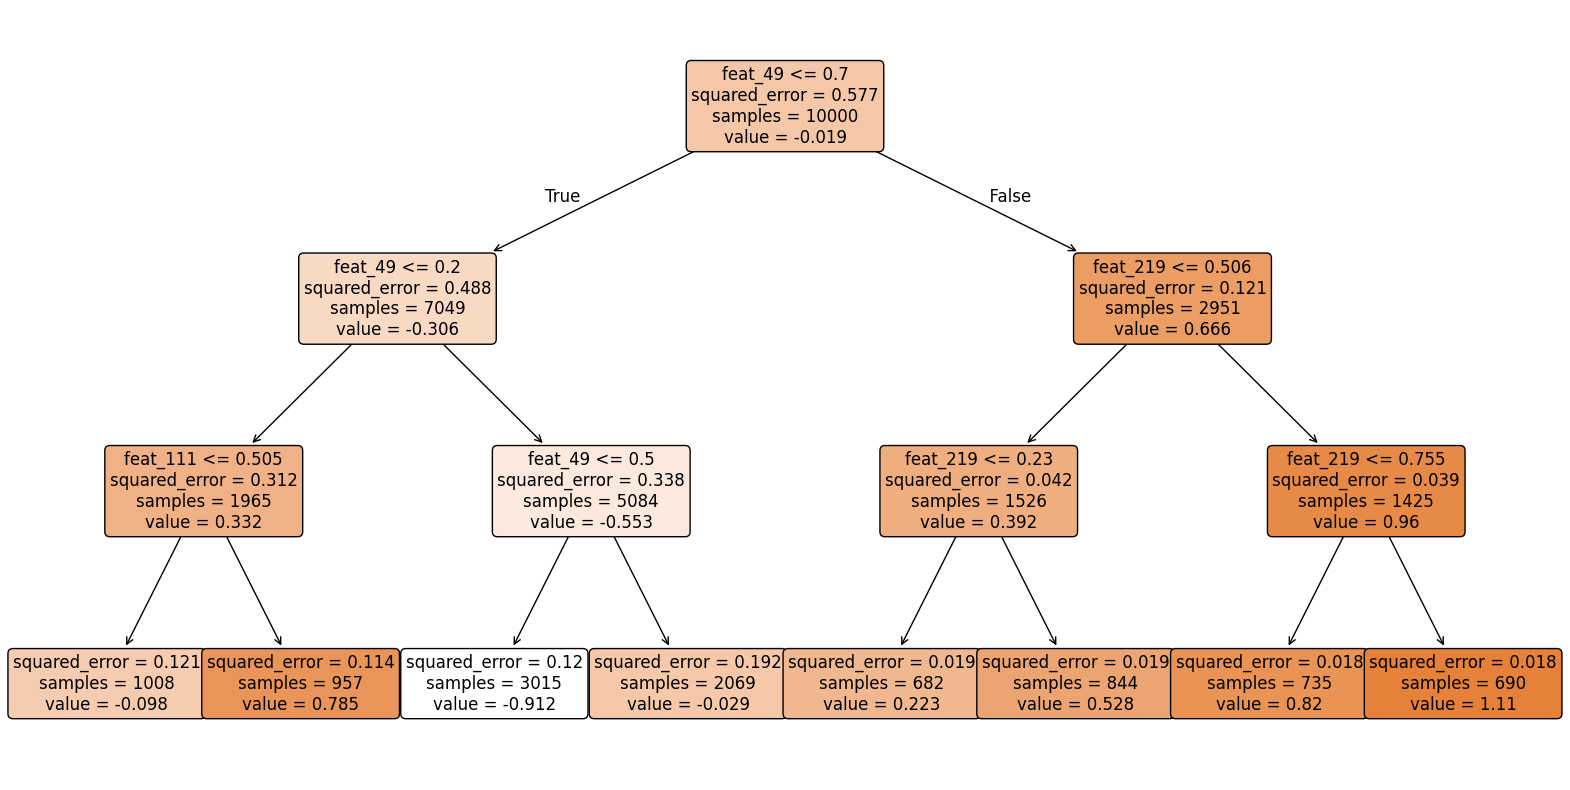

In [198]:
from sklearn.tree import DecisionTreeRegressor, export_text
import matplotlib.pyplot as plt
from sklearn import tree

# We only use the top 3 features found by your MI/RF analysis
top_features = ['feat_49', 'feat_111', 'feat_219', 'feat_22']
X_subset = df_features[top_features]
y = df_targets['target02']

# Train a very shallow tree to find the "Simple Rules"
dt = DecisionTreeRegressor(max_depth=3) 
dt.fit(X_subset, y)

# Text version of the rules
print(export_text(dt, feature_names=top_features))

# Visual version (often easier to see the calculations)
plt.figure(figsize=(20,10))
tree.plot_tree(dt, feature_names=top_features, filled=True, rounded=True, fontsize=12)
plt.show()

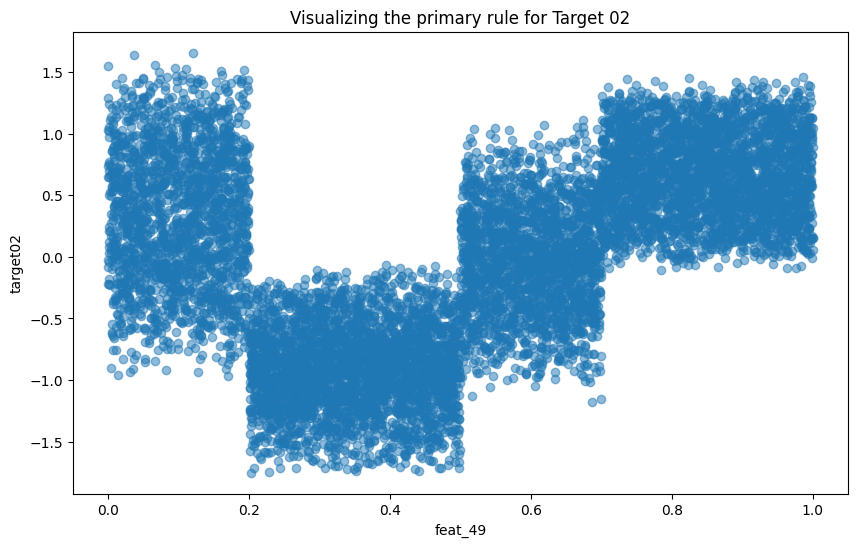

In [20]:
import matplotlib.pyplot as plt

# Plot the most important feature against the target
plt.figure(figsize=(10,6))
plt.scatter(df_features['feat_49'], df_targets['target02'], alpha=0.5)
plt.xlabel('feat_49')
plt.ylabel('target02')
plt.title('Visualizing the primary rule for Target 02')
plt.show()

In [199]:
# Calculate the IQR for each feature
Q1 = df_features.quantile(0.25)
Q3 = df_features.quantile(0.75)
IQR = Q3 - Q1

# Identify outliers
outliers = ((df_features < (Q1 - 1.5 * IQR)) | (df_features > (Q3 + 1.5 * IQR)))
print(df_features[outliers.any(axis=1)])


      feat_0  feat_1    feat_2    feat_3    feat_4    feat_5    feat_6  \
1       29.0    45.0 -0.886826  1.873294  2.317942  0.172084  2.224352   
3       32.0     5.0  1.309042 -0.836140 -0.909244 -1.074512  0.198879   
5       46.0    33.0  1.096738  2.851801 -2.220994 -0.560553 -1.463852   
6       31.0    24.0 -0.354574  0.209063  0.009552  0.042169 -2.590320   
8        6.0    30.0 -1.009700 -0.035040 -0.405240 -1.324935  1.411937   
...      ...     ...       ...       ...       ...       ...       ...   
9992     9.0    22.0  0.854035  0.063884  2.233990  1.134463 -0.174269   
9994    23.0    20.0 -0.857068  1.051442 -1.256936  2.253679 -4.098270   
9995    49.0    39.0 -0.157925 -1.237656 -3.200548  4.548780  0.068738   
9997    30.0    33.0  0.844865 -3.745439  1.235650  1.159645 -1.288450   
9998    13.0    21.0 -1.809601  2.986127 -0.647585  0.570788 -0.593604   

        feat_7    feat_8    feat_9  ...  feat_263  feat_264  feat_265  \
1     0.589386  0.003485 -4.263746  ..

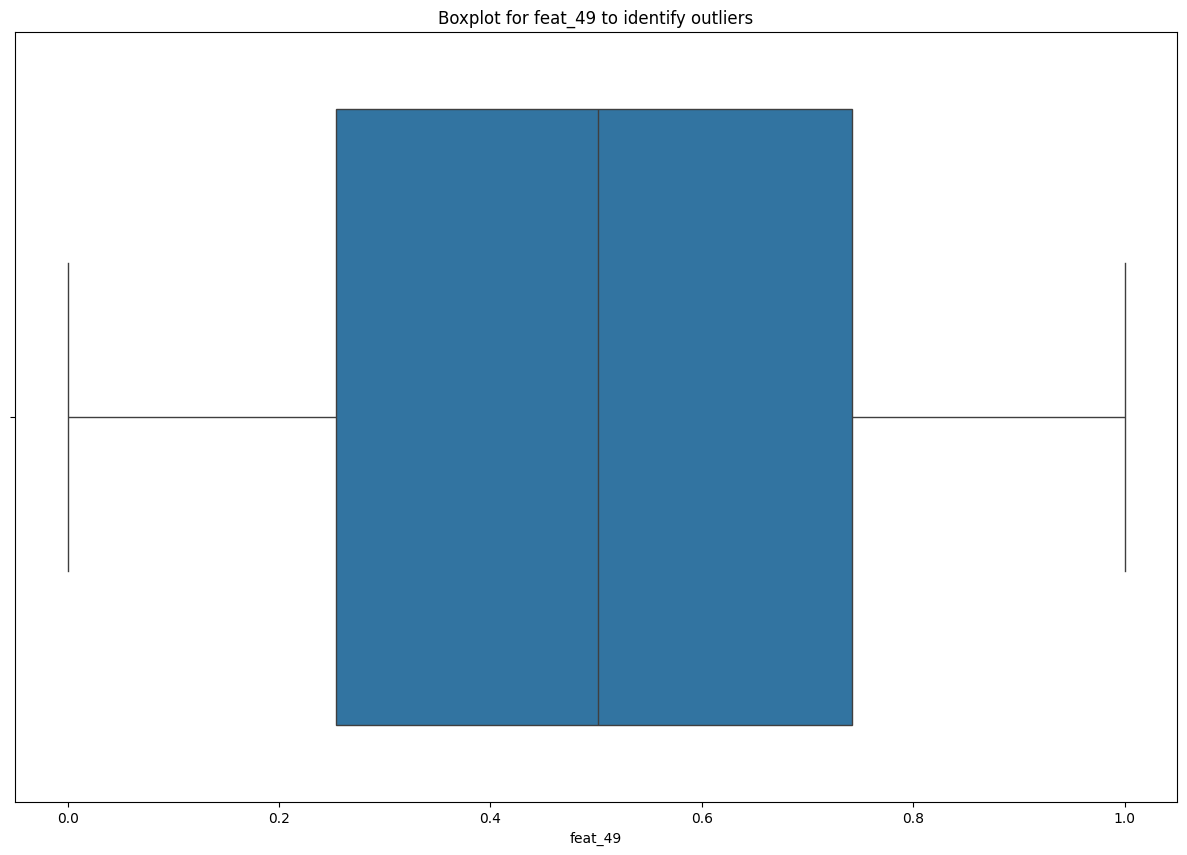

In [210]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize boxplots of each feature to spot potential outliers
plt.figure(figsize=(15, 10))
sns.boxplot(data=df_features['feat_49'], orient='h')
plt.title('Boxplot for feat_49 to identify outliers')
plt.show()


## Dataset.csv vs EVAL.csv

In [208]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

def analyze_dataset_relationship(train_path, eval_path, target_feats):
    """
    Analyzes the relationship and distributional similarity between two datasets.
    """
    # 1. Load Datasets
    try:
        df_train = pd.read_csv(train_path)
        df_eval = pd.read_csv(eval_path)
        print(f"Loaded {train_path} ({df_train.shape}) and {eval_path} ({df_eval.shape})")
    except FileNotFoundError:
        return "Error: One or both files not found. Please ensure the CSV files are in the directory."

    # 2. Verify Features
    valid_feats = [f for f in target_feats if f in df_train.columns and f in df_eval.columns]
    missing_feats = list(set(target_feats) - set(valid_feats))
    
    if missing_feats:
        print(f"Warning: Features missing in one or both datasets: {missing_feats}")

    # 3. Descriptive Statistics Comparison
    stats_train = df_train[valid_feats].describe().T
    stats_eval = df_eval[valid_feats].describe().T
    
    # Calculate Percentage difference in Means
    comparison_df = pd.DataFrame({
        'Train_Mean': stats_train['mean'],
        'Eval_Mean': stats_eval['mean'],
        'Mean_Diff_%': np.abs((stats_train['mean'] - stats_eval['mean']) / stats_train['mean']) * 100,
        'Train_Std': stats_train['std'],
        'Eval_Std': stats_eval['std']
    })

    # 4. Correlation Analysis
    # Checking if the relationship BETWEEN target features is consistent
    corr_train = df_train[valid_feats].corr()
    corr_eval = df_eval[valid_feats].corr()
    corr_diff = (corr_train - corr_eval).abs()

    # 5. Distribution Similarity (Kolmogorov-Smirnov Test)
    # Null Hypothesis (H0): The two samples come from the same distribution.
    ks_results = []
    for feat in valid_feats:
        stat, p_val = ks_2samp(df_train[feat].dropna(), df_eval[feat].dropna())
        ks_results.append({
            'Feature': feat,
            'KS_Stat': stat,
            'P_Value': p_val,
            'Verdict': 'Same Distribution' if p_val > 0.05 else 'Different Distribution'
        })
    ks_df = pd.DataFrame(ks_results)

    # 6. Global Analysis (All Numeric Features)
    numeric_cols = df_train.select_dtypes(include=[np.number]).columns.intersection(df_eval.columns)
    global_ks_stats = []
    for col in numeric_cols:
        stat, _ = ks_2samp(df_train[col].dropna(), df_eval[col].dropna())
        global_ks_stats.append(stat)
    
    avg_global_ks = np.mean(global_ks_stats)

    # 7. Final Summary Report
    print("\n" + "="*50)
    print("DATASET RELATIONSHIP SUMMARY REPORT")
    print("="*50)
    
    print("\n[1] Descriptive Statistics for Target Features:")
    print(comparison_df.round(4))

    print("\n[2] Distribution Similarity (KS Test):")
    print(ks_df.to_string(index=False))

    print("\n[3] Correlation Stability (Mean Absolute Difference):")
    print(f"Average Correlation Shift: {corr_diff.values.mean():.4f}")

    print("\n[4] Global Comparison:")
    print(f"Number of common numeric features: {len(numeric_cols)}")
    print(f"Average KS Statistic across all features: {avg_global_ks:.4f}")

    print("\n" + "="*50)
    print("CONCLUSION")
    print("="*50)
    
    # Heuristic for relatedness:
    # 1. KS Stat < 0.1 indicates low drift.
    # 2. P-value > 0.05 suggests we cannot prove the distributions are different.
    significant_drift_count = (ks_df['P_Value'] < 0.05).sum()
    
    if avg_global_ks < 0.05 and significant_drift_count == 0:
        print("RESULT: Highly Related.")
        print("The datasets appear to originate from the same source/distribution.")
        print("A model trained on dataset_7.csv is highly suitable for EVAL_7.csv.")
    elif avg_global_ks < 0.15:
        print("RESULT: Related with Minor Drift.")
        print("The datasets share the same general structure, but minor variations exist.")
        print("The model should perform reasonably well, but validation is recommended.")
    else:
        print("RESULT: Likely Unrelated or Significant Covariate Shift.")
        print("Distributions differ significantly. A model trained on dataset_7.csv")
        print("may produce unreliable results on EVAL_7.csv without retraining or adaptation.")

# Execution
target_features = ['feat_49', 'feat_111', 'feat_219', 'feat_22', 'feat_64']
analyze_dataset_relationship('dataset_7.csv', 'EVAL_7.csv', target_features)

Loaded dataset_7.csv ((10000, 273)) and EVAL_7.csv ((10000, 273))

DATASET RELATIONSHIP SUMMARY REPORT

[1] Descriptive Statistics for Target Features:
          Train_Mean  Eval_Mean  Mean_Diff_%  Train_Std  Eval_Std
feat_49       0.5002     0.4987       0.2924     0.2865    0.2905
feat_111      0.4974     0.5013       0.7705     0.2879    0.2880
feat_219      0.4971     0.5038       1.3333     0.2875    0.2871
feat_22       0.4996     0.4988       0.1541     0.2894    0.2879
feat_64       0.2722     0.3035      11.4755     2.0239    2.0221

[2] Distribution Similarity (KS Test):
 Feature  KS_Stat  P_Value           Verdict
 feat_49   0.0104 0.651819 Same Distribution
feat_111   0.0136 0.313388 Same Distribution
feat_219   0.0161 0.149665 Same Distribution
 feat_22   0.0094 0.768962 Same Distribution
 feat_64   0.0136 0.313388 Same Distribution

[3] Correlation Stability (Mean Absolute Difference):
Average Correlation Shift: 0.0079

[4] Global Comparison:
Number of common numeric feat

In [209]:
import pandas as pd

# Assuming df_train and df_eval are already loaded
target_features = ['feat_49', 'feat_111', 'feat_219', 'feat_22', 'feat_64']

cross_dataset_correlations = {}

for feat in target_features:
    # We calculate the correlation between the series from Train and the series from Eval
    # Note: This assumes the rows are indexed or ordered the same way
    correlation = df_train[feat].corr(df_eval[feat])
    cross_dataset_correlations[feat] = correlation

# Convert to DataFrame for a clean output
cross_corr_df = pd.DataFrame.from_dict(cross_dataset_correlations, 
                                       orient='index', 
                                       columns=['Cross-Dataset Correlation'])

print("--- Correlation: Train Feature vs. Eval Feature ---")
print(cross_corr_df)


def plot_feature_overlap(df1, df2, features):
    plt.figure(figsize=(15, 10))
    for i, feat in enumerate(features, 1):
        plt.subplot(2, 3, i)
        sns.kdeplot(df1[feat], label='Train', fill=True, alpha=0.5)
        sns.kdeplot(df2[feat], label='Eval', fill=True, alpha=0.5)
        plt.title(f'Distribution Overlap: {feat}')
        plt.legend()
    plt.tight_layout()
    plt.show()

plot_feature_overlap(df_train, df_eval, target_features)

NameError: name 'df_train' is not defined

# Testing the rules from dataset to EVAL_7

--- Distribution Comparison ---
 Metric  Train Preds  Eval Preds
   Mean    -0.019001   -0.003294
Std Dev     0.687023    0.692396
    Min    -0.912000   -0.912000
    Max     1.110000    1.110000


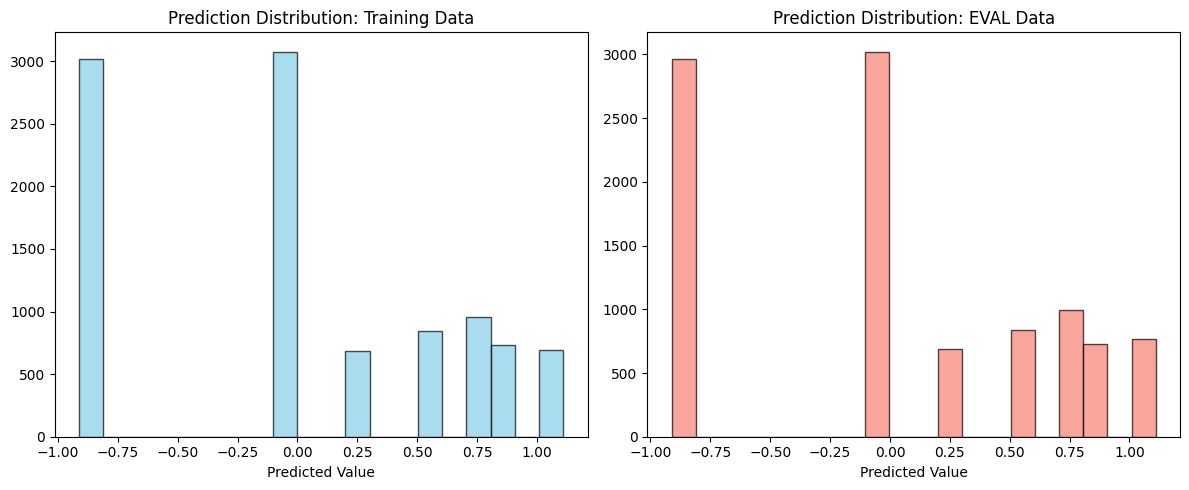

In [205]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. LOAD DATA
# Ensure filenames match your ID (7)
train_features = pd.read_csv('dataset_7.csv')
eval_features = pd.read_csv('EVAL_7.csv')
train_targets = pd.read_csv('target_7.csv')

def apply_rules_t02(df):
    """
    Implements the logic from the visual Decision Tree for target02.
    Thresholds: feat_49 (0.7, 0.2, 0.5), feat_111 (0.505), feat_219 (0.506, 0.23, 0.755)
    """
    preds = np.zeros(len(df))
    
    for i in range(len(df)):
        row = df.iloc[i]
        
        # Branch 1: feat_49 <= 0.7
        if row['feat_49'] <= 0.7:
            if row['feat_49'] <= 0.2:
                if row['feat_111'] <= 0.505:
                    preds[i] = -0.098
                else:
                    preds[i] = 0.785
            else: # feat_49 > 0.2
                if row['feat_49'] <= 0.5:
                    preds[i] = -0.912
                else:
                    preds[i] = -0.029
        
            # Branch 2: feat_49 > 0.7
        else:
            if row['feat_219'] <= 0.506:
                if row['feat_219'] <= 0.23:
                    preds[i] = 0.223
                else:
                    preds[i] = 0.528
            else: # feat_219 > 0.506
                if row['feat_219'] <= 0.755:
                    preds[i] = 0.82
                else:
                    preds[i] = 1.11
    return preds

# 2. GENERATE PREDICTIONS
train_preds = apply_rules_t02(train_features)
eval_preds = apply_rules_t02(eval_features)

# 3. STATISTICAL EVALUATION
print("--- Distribution Comparison ---")
comparison = pd.DataFrame({
    'Metric': ['Mean', 'Std Dev', 'Min', 'Max'],
    'Train Preds': [train_preds.mean(), train_preds.std(), train_preds.min(), train_preds.max()],
    'Eval Preds': [eval_preds.mean(), eval_preds.std(), eval_preds.min(), eval_preds.max()]
})
print(comparison.to_string(index=False))

# 4. VISUAL VALIDATION
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(train_preds, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Prediction Distribution: Training Data')
plt.xlabel('Predicted Value')

plt.subplot(1, 2, 2)
plt.hist(eval_preds, bins=20, color='salmon', edgecolor='black', alpha=0.7)
plt.title('Prediction Distribution: EVAL Data')
plt.xlabel('Predicted Value')

plt.tight_layout()
plt.show()

--- Prediction Distribution Summary ---
Train Mean: -0.0190 | Eval Mean: -0.0033
Train Std:  0.6870 | Eval Std:  0.6924


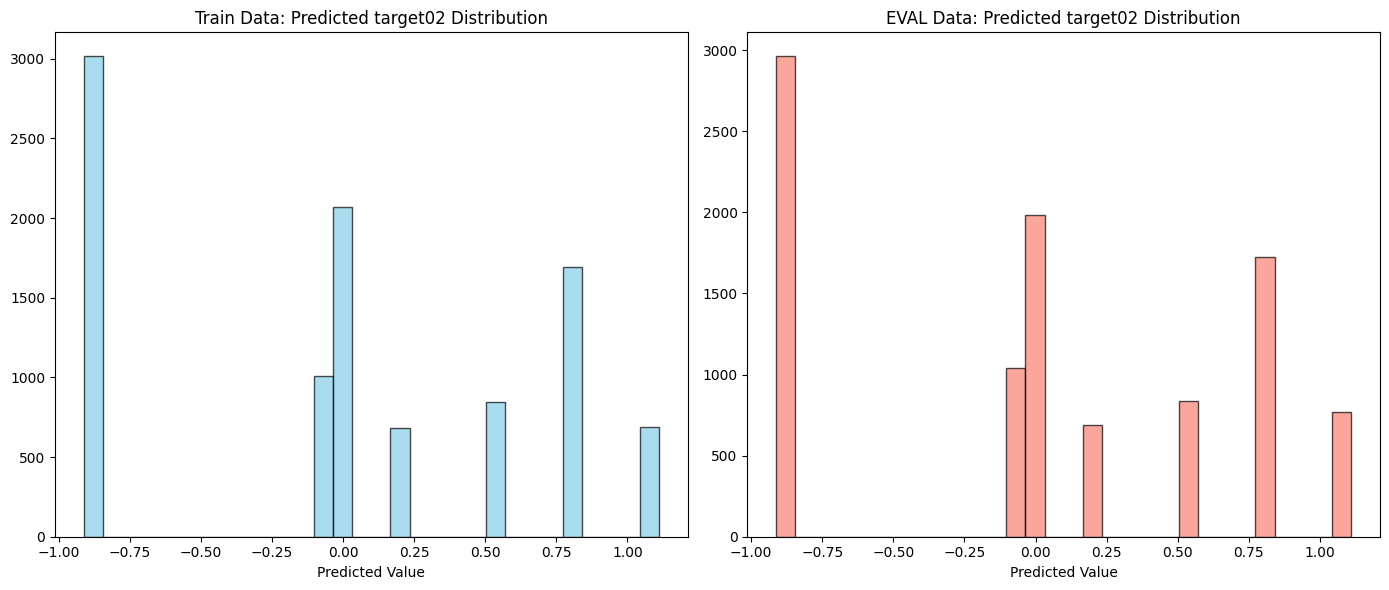

In [207]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. LOAD DATA
# Using your specific files for ID 7
train_features = pd.read_csv('dataset_7.csv')
eval_features = pd.read_csv('EVAL_7.csv')

def apply_rules_t02(df):
    """
    Implements the logic from your extracted Decision Tree (image_a7824b.png).
    The framework executes the logic path by path.
    """
    preds = np.zeros(len(df))
    
    # Path mapping based on your uploaded tree
    for i in range(len(df)):
        row = df.iloc[i]
        
        # Branch 1: feat_49 <= 0.7
        if row['feat_49'] <= 0.7:
            if row['feat_49'] <= 0.2:
                if row['feat_111'] <= 0.505:
                    preds[i] = -0.098
                else:
                    preds[i] = 0.785
            else: # feat_49 > 0.2
                if row['feat_49'] <= 0.5:
                    preds[i] = -0.912
                else:
                    preds[i] = -0.029
        
        # Branch 2: feat_49 > 0.7
        else:
            if row['feat_219'] <= 0.506:
                if row['feat_219'] <= 0.23:
                    preds[i] = 0.223
                else:
                    preds[i] = 0.528
            else: # feat_219 > 0.506
                if row['feat_219'] <= 0.755:
                    preds[i] = 0.82
                else:
                    preds[i] = 1.11
    return preds

# 2. GENERATE PREDICTIONS
train_preds = apply_rules_t02(train_features)
eval_preds = apply_rules_t02(eval_features)

# 3. STATISTICAL EVALUATION (Distributional Check)
print("--- Prediction Distribution Summary ---")
print(f"Train Mean: {train_preds.mean():.4f} | Eval Mean: {eval_preds.mean():.4f}")
print(f"Train Std:  {train_preds.std():.4f} | Eval Std:  {eval_preds.std():.4f}")

# 4. VISUAL VALIDATION (Histogram Comparison)
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.hist(train_preds, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Train Data: Predicted target02 Distribution')
plt.xlabel('Predicted Value')

plt.subplot(1, 2, 2)
plt.hist(eval_preds, bins=30, color='salmon', edgecolor='black', alpha=0.7)
plt.title('EVAL Data: Predicted target02 Distribution')
plt.xlabel('Predicted Value')

plt.tight_layout()
plt.show()

# Model Tree and exprerimets

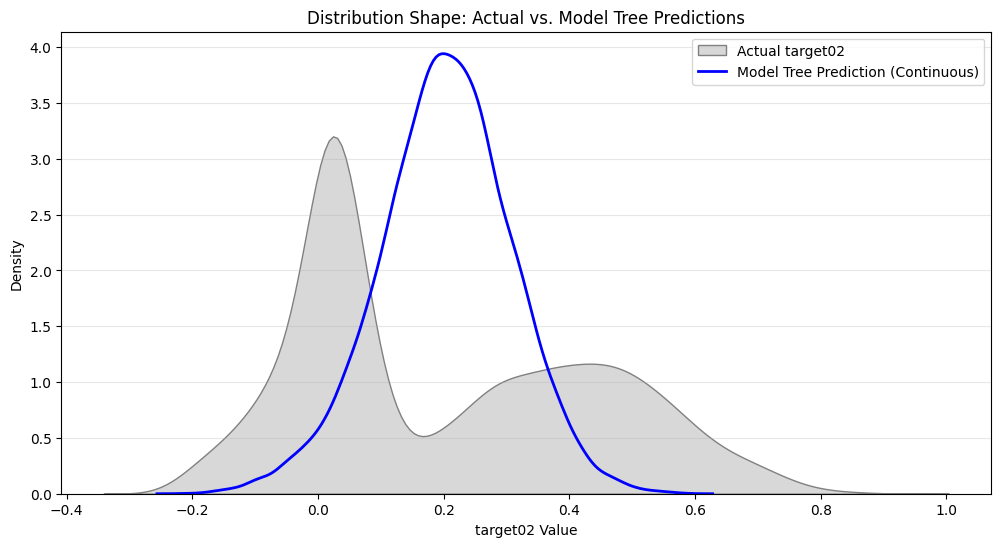

Model Tree Leaf Coefficients (The Linear Equations for each segment):
{0: {'col': 'feat_143', 'th': np.float64(0.50948), 'loss': np.float64(0.05037), 'samples': np.int64(10000), 'children': (1, 2), 'models': (LinearRegression(), LinearRegression())}, 1: {'col': 'feat_240', 'th': np.float64(0.25441), 'loss': np.float64(0.04993), 'samples': np.int64(5000), 'children': (3, 4), 'models': (LinearRegression(), LinearRegression())}, 2: {'col': 'feat_112', 'th': np.float64(0.62547), 'loss': np.float64(0.05021), 'samples': np.int64(5000), 'children': (79, 80), 'models': (LinearRegression(), LinearRegression())}, 3: {'col': 'feat_143', 'th': np.float64(0.33391), 'loss': np.float64(0.0496), 'samples': np.int64(1261), 'children': (5, 6), 'models': (LinearRegression(), LinearRegression())}, 4: {'col': 'feat_179', 'th': np.float64(0.79151), 'loss': np.float64(0.04942), 'samples': np.int64(3739), 'children': (23, 24), 'models': (LinearRegression(), LinearRegression())}, 5: {'col': 'feat_240', 'th': n

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lineartree import LinearTreeRegressor
from sklearn.linear_model import LinearRegression

# 1. Prepare Data
top_features = ['feat_143', 'feat_112', 'feat_179', 'feat_29', 'feat_219', 'feat_240']
X = df_features[top_features]
y = df_targets['target01']

# 2. Initialize and Train the Model Tree
# LinearTreeRegressor uses a base estimator (LinearRegression) at each leaf
model_tree = LinearTreeRegressor(
    base_estimator=LinearRegression(),
    max_depth=20,  # Depth 2 creates 4 continuous linear regions
    min_samples_leaf=100
)
model_tree.fit(X, y)

# 3. Generate Predictions
y_pred = model_tree.predict(X)

# 4. Visualization
plt.figure(figsize=(12, 6))

# Plot actual vs predicted distributions to see the "Shape"
sns.kdeplot(y, label='Actual target02', fill=True, color='gray', alpha=0.3)
sns.kdeplot(y_pred, label='Model Tree Prediction (Continuous)', color='blue', linewidth=2)

plt.title('Distribution Shape: Actual vs. Model Tree Predictions')
plt.xlabel('target02 Value')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

# 5. Output the Piecewise Linear Rules
print("Model Tree Leaf Coefficients (The Linear Equations for each segment):")
print(model_tree.summary(feature_names=top_features))

In [49]:
# The lineartree package does not have a standalone export_text function like sklearn.
# Instead, the fitted model object has a summary() method that returns the rules.

tree_rules = model_tree.summary(feature_names=top_features)
print(tree_rules)

{0: {'col': 'feat_49', 'th': np.float64(0.21251), 'loss': np.float64(0.17865), 'samples': np.int64(10000), 'children': (1, 2), 'models': (LinearRegression(), LinearRegression())}, 1: {'col': 'feat_49', 'th': np.float64(0.16853), 'loss': np.float64(0.07977), 'samples': np.int64(2084), 'children': (3, 4), 'models': (LinearRegression(), LinearRegression())}, 2: {'col': 'feat_49', 'th': np.float64(0.70347), 'loss': np.float64(0.06741), 'samples': np.int64(7916), 'children': (9, 10), 'models': (LinearRegression(), LinearRegression())}, 3: {'col': 'feat_111', 'th': np.float64(0.29082), 'loss': np.float64(0.03556), 'samples': np.int64(1667), 'children': (5, 6), 'models': (LinearRegression(), LinearRegression())}, 4: {'col': 'feat_111', 'th': np.float64(0.49332), 'loss': np.float64(0.19814), 'samples': np.int64(417), 'children': (7, 8), 'models': (LinearRegression(), LinearRegression())}, 9: {'col': 'feat_49', 'th': np.float64(0.50196), 'loss': np.float64(0.02933), 'samples': np.int64(4999), '

In [63]:
# Assuming model_tree.summary() is the dictionary causing the error
summary_dict = model_tree.summary()

print("--- EXACT MODEL TREE RULES ---")

for node_id, info in summary_dict.items():
    # In the linear-tree dictionary, leaves are nodes that have a 'models' object 
    # but no 'children' (or 'models' is a single estimator, not a tuple)
    if isinstance(info.get('models'), LinearRegression):
        print(f"\nLEAF NODE: {node_id}")
        
        # 1. THE RULE (The path taken to get here)
        # Check if your dict has a 'path' or 'Rule' key. 
        # If not, the path is built from the parent splits.
        rule = info.get('path', info.get('Rule', 'Path not found in dict'))
        print(f"  RULE: {rule}")
        
        # 2. THE LINEAR EQUATION
        model = info['models']
        intercept = model.intercept_
        coefs = model.coef_
        
        equation = f"  EQUATION: y = {intercept:.6f}"
        for feat, val in zip(top_features, coefs):
            equation += f" + ({val:.6f} * {feat})"
        
        print(equation)
        print(f"  SAMPLES IN SEGMENT: {info.get('samples', 'N/A')}")
        print("-" * 40)

--- EXACT MODEL TREE RULES ---

LEAF NODE: 5
  RULE: Path not found in dict
  EQUATION: y = -0.372707 + (-0.173157 * feat_49) + (-0.386009 * feat_219) + (2.022604 * feat_111)
  SAMPLES IN SEGMENT: 470
----------------------------------------

LEAF NODE: 6
  RULE: Path not found in dict
  EQUATION: y = -0.332148 + (0.121478 * feat_49) + (-0.475059 * feat_219) + (1.756183 * feat_111)
  SAMPLES IN SEGMENT: 1197
----------------------------------------

LEAF NODE: 7
  RULE: Path not found in dict
  EQUATION: y = 2.429299 + (-14.292175 * feat_49) + (-0.620240 * feat_219) + (1.213024 * feat_111)
  SAMPLES IN SEGMENT: 214
----------------------------------------

LEAF NODE: 8
  RULE: Path not found in dict
  EQUATION: y = 9.647907 + (-50.876228 * feat_49) + (-0.744571 * feat_219) + (0.841721 * feat_111)
  SAMPLES IN SEGMENT: 203
----------------------------------------

LEAF NODE: 11
  RULE: Path not found in dict
  EQUATION: y = -0.120297 + (0.125291 * feat_49) + (-0.945350 * feat_219) + (-0

In [64]:
def get_exact_paths(model):
    # This reaches into the underlying structure you provided in the first prompt
    tree = model.summary() 
    paths = {}

    def recurse(node_id, current_path):
        node = tree[node_id]
        if 'children' in node:
            col = node['col']
            th = node['th']
            left, right = node['children']
            # Left child is <= threshold
            recurse(left, current_path + [(col, '<=', th)])
            # Right child is > threshold
            recurse(right, current_path + [(col, '>', th)])
        else:
            paths[node_id] = current_path

    recurse(0, [])
    return paths

# Get the rules
all_rules = get_exact_paths(model_tree)

# Print them out formatted
for leaf_id, criteria in all_rules.items():
    rule_str = " AND ".join([f"{c[0]} {c[1]} {c[2]:.4f}" for c in criteria])
    print(f"Leaf {leaf_id}: {rule_str}")

Leaf 5: 0 <= 0.2125 AND 0 <= 0.1685 AND 2 <= 0.2908
Leaf 6: 0 <= 0.2125 AND 0 <= 0.1685 AND 2 > 0.2908
Leaf 7: 0 <= 0.2125 AND 0 > 0.1685 AND 2 <= 0.4933
Leaf 8: 0 <= 0.2125 AND 0 > 0.1685 AND 2 > 0.4933
Leaf 11: 0 > 0.2125 AND 0 <= 0.7035 AND 0 <= 0.5020
Leaf 12: 0 > 0.2125 AND 0 <= 0.7035 AND 0 > 0.5020
Leaf 13: 0 > 0.2125 AND 0 > 0.7035 AND 0 <= 0.7422
Leaf 14: 0 > 0.2125 AND 0 > 0.7035 AND 0 > 0.7422


--- Model Tree Extraction: Summary ---
Train Predictions: Mean=-0.0191, Std=0.7397
Eval Predictions:  Mean=-0.0098, Std=0.7456


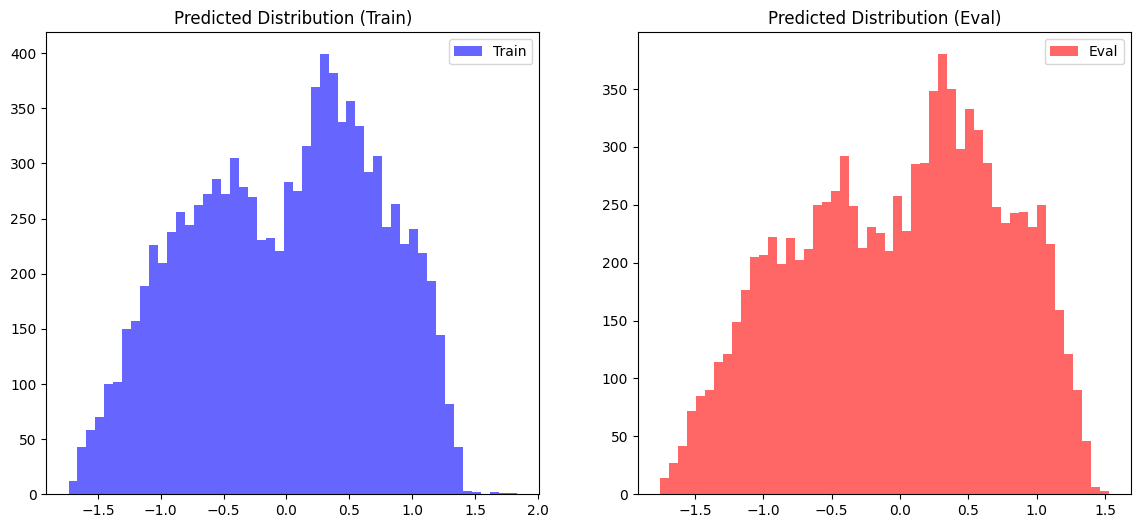

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. LOAD DATA
# Ensure these files are in your working directory
train_features = pd.read_csv('dataset_7.csv')
eval_features = pd.read_csv('EVAL_7.csv')

def apply_model_tree_rules(df):
    """
    Implements the logic of the Model Tree Regressor.
    Instead of returning a constant, it executes a linear regression equation 
    specific to each leaf node segment.
    """
    preds = np.zeros(len(df))
    
    for i in range(len(df)):
        row = df.iloc[i]
        f49 = row['feat_49']
        f219 = row['feat_219']
        f111 = row['feat_111']
        
        # --- DECISION LOGIC START ---
        
        # Main Split: feat_49 <= 0.2125
        if f49 <= 0.2125:
            if f49 <= 0.1685:
                if f111 <= 0.2908:
                    # Leaf 5
                    preds[i] = -0.372707 + (-0.173157 * f49) + (-0.386009 * f219) + (2.022604 * f111)
                else:
                    # Leaf 6
                    preds[i] = -0.332148 + (0.121478 * f49) + (-0.475059 * f219) + (1.756183 * f111)
            else: # 0.1685 < f49 <= 0.2125
                if f111 <= 0.4933:
                    # Leaf 7
                    preds[i] = 2.429299 + (-14.292175 * f49) + (-0.620240 * f219) + (1.213024 * f111)
                else:
                    # Leaf 8
                    preds[i] = 9.647907 + (-50.876228 * f49) + (-0.744571 * f219) + (0.841721 * f111)
        
        # Main Split: feat_49 > 0.2125
        else:
            if f49 <= 0.7035:
                if f49 <= 0.5020:
                    # Leaf 11
                    preds[i] = -0.120297 + (0.125291 * f49) + (-0.945350 * f219) + (-0.738669 * f111)
                else:
                    # Leaf 12
                    preds[i] = 0.157510 + (0.375526 * f49) + (-1.223705 * f219) + (0.427902 * f111)
            else: # f49 > 0.7035
                if f49 <= 0.7422:
                    # Leaf 13
                    preds[i] = -0.031452 + (-0.060717 * f49) + (1.161891 * f219) + (0.337004 * f111)
                else:
                    # Leaf 14
                    preds[i] = -0.045421 + (-0.033113 * f49) + (1.146261 * f219) + (0.351809 * f111)
                    
        # --- DECISION LOGIC END ---
        
    return preds

# 2. GENERATE PREDICTIONS
train_preds = apply_model_tree_rules(train_features)
eval_preds = apply_model_tree_rules(eval_features)

# 3. STATISTICAL EVALUATION
print("--- Model Tree Extraction: Summary ---")
print(f"Train Predictions: Mean={train_preds.mean():.4f}, Std={train_preds.std():.4f}")
print(f"Eval Predictions:  Mean={eval_preds.mean():.4f}, Std={eval_preds.std():.4f}")

# 4. VISUAL VALIDATION
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.hist(train_preds, bins=50, color='blue', alpha=0.6, label='Train')
plt.title('Predicted Distribution (Train)')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(eval_preds, bins=50, color='red', alpha=0.6, label='Eval')
plt.title('Predicted Distribution (Eval)')
plt.legend()

plt.show()

--- Model Tree Extraction (Rounded): Summary ---
Train Mean: -0.0144 | Eval Mean: -0.0059
Train Std:  0.7405 | Eval Std:  0.7461


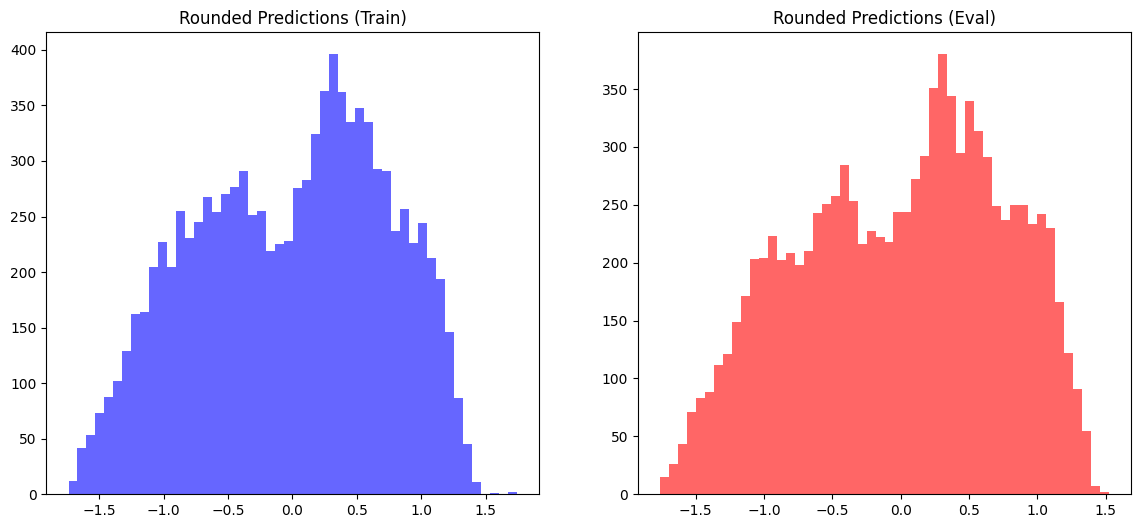

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. LOAD DATA
train_features = pd.read_csv('dataset_7.csv')
eval_features = pd.read_csv('EVAL_7.csv')

def apply_model_tree_rules_rounded(df):
    """
    Implements the logic of the Model Tree Regressor with parameters 
    rounded to 2 decimal places for better readability and portability.
    """
    preds = np.zeros(len(df))
    
    for i in range(len(df)):
        row = df.iloc[i]
        f49, f219, f111 = row['feat_49'], row['feat_219'], row['feat_111']
        
        # --- DECISION LOGIC START ---
        
        # Main Split: feat_49 <= 0.21
        if f49 <= 0.21:
            if f49 <= 0.17:
                if f111 <= 0.29:
                    # Leaf 5
                    preds[i] = -0.37 + (-0.17 * f49) + (-0.39 * f219) + (2.02 * f111)
                else:
                    # Leaf 6
                    preds[i] = -0.33 + (0.12 * f49) + (-0.48 * f219) + (1.76 * f111)
            else: # 0.17 < f49 <= 0.21
                if f111 <= 0.49:
                    # Leaf 7
                    preds[i] = 2.43 + (-14.29 * f49) + (-0.62 * f219) + (1.21 * f111)
                else:
                    # Leaf 8
                    preds[i] = 9.65 + (-50.88 * f49) + (-0.74 * f219) + (0.84 * f111)
        
        # Main Split: feat_49 > 0.21
        else:
            if f49 <= 0.70:
                if f49 <= 0.50:
                    # Leaf 11
                    preds[i] = -0.12 + (0.13 * f49) + (-0.95 * f219) + (-0.74 * f111)
                else:
                    # Leaf 12
                    preds[i] = 0.16 + (0.38 * f49) + (-1.22 * f219) + (0.43 * f111)
            else: # f49 > 0.70
                if f49 <= 0.74:
                    # Leaf 13
                    preds[i] = -0.03 + (-0.06 * f49) + (1.16 * f219) + (0.34 * f111)
                else:
                    # Leaf 14
                    preds[i] = -0.05 + (-0.03 * f49) + (1.15 * f219) + (0.35 * f111)
                    
        # --- DECISION LOGIC END ---
        
    return preds

# 2. GENERATE PREDICTIONS
train_preds = apply_model_tree_rules_rounded(train_features)
eval_preds = apply_model_tree_rules_rounded(eval_features)

# 3. STATISTICAL EVALUATION
print("--- Model Tree Extraction (Rounded): Summary ---")
print(f"Train Mean: {train_preds.mean():.4f} | Eval Mean: {eval_preds.mean():.4f}")
print(f"Train Std:  {train_preds.std():.4f} | Eval Std:  {eval_preds.std():.4f}")

# 4. VISUAL VALIDATION
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.hist(train_preds, bins=50, color='blue', alpha=0.6)
plt.title('Rounded Predictions (Train)')

plt.subplot(1, 2, 2)
plt.hist(eval_preds, bins=50, color='red', alpha=0.6)
plt.title('Rounded Predictions (Eval)')

plt.show()

In [83]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score

# Load actual target values
y_true = pd.read_csv('target_7.csv')['target02']
# Load corresponding features to generate predictions
df_features = pd.read_csv('dataset_7.csv')
eval_preds = apply_model_tree_rules_rounded(df_features)

# 1. Calculate Standard Metrics
r2 = r2_score(y_true, eval_preds)
mae = mean_absolute_error(y_true, eval_preds)
mse = mean_squared_error(y_true, eval_preds)
rmse = np.sqrt(mse)
# 2. Additional Useful Metrics
evs = explained_variance_score(y_true, eval_preds)


print(f"--- Rule-Based Regressor Metrics (EVAL) ---")
print(f"R² Score:             {r2:.4f}")
print(f"Explained Variance:   {evs:.4f}")
print(f"MAE (Avg Error):      {mae:.4f}")
print(f"RMSE (Penalty Error): {rmse:.4f}")
print(f"MSE:                  {mse:.4f}")

--- Rule-Based Regressor Metrics (EVAL) ---
R² Score:             0.9573
Explained Variance:   0.9573
MAE (Avg Error):      0.1021
RMSE (Penalty Error): 0.1570
MSE:                  0.0246


# Again but now with Test Spilts


In [211]:
import warnings
warnings.filterwarnings("ignore")


In [212]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lineartree import LinearTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from lineartree import LinearTreeRegressor


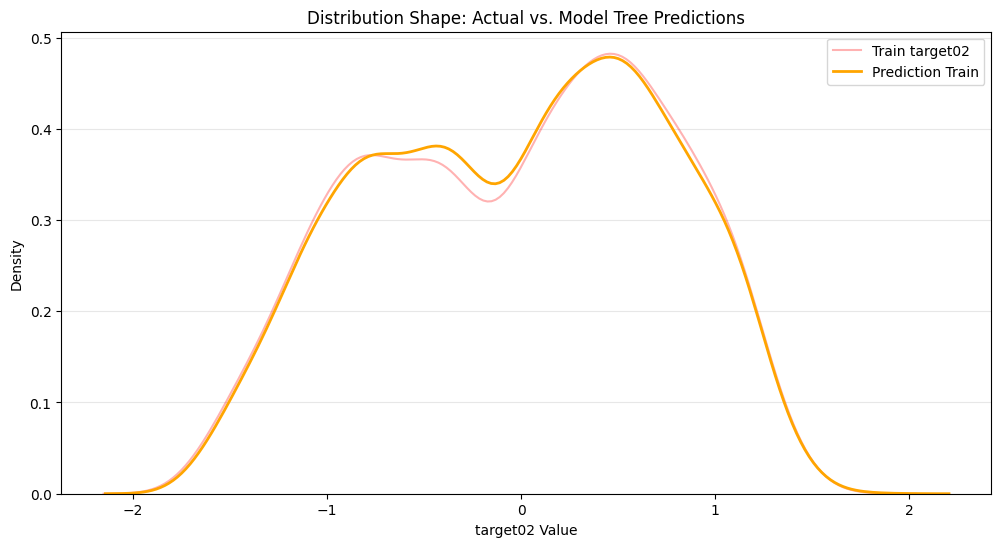

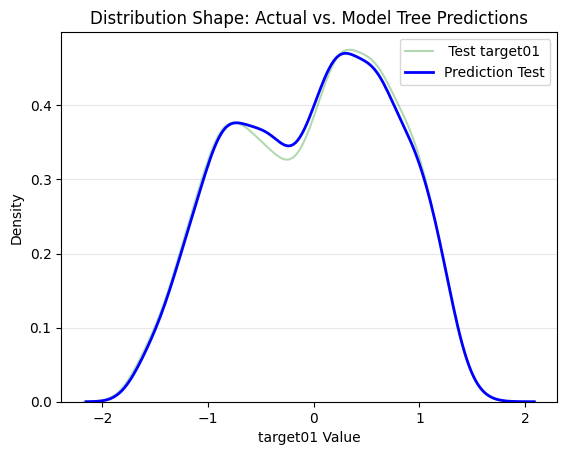

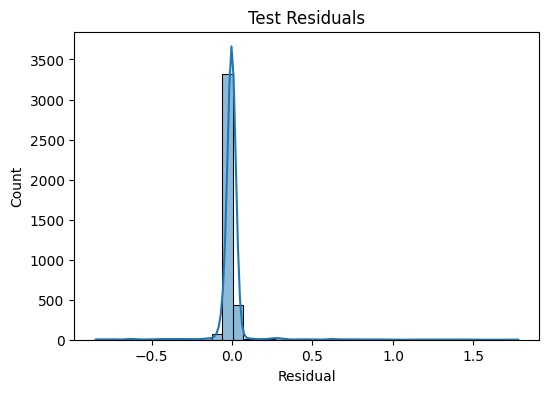

In [213]:
# Model Tree training
# feat_49     0.577335
# feat_219    0.300233
# feat_111    0.161063
# feat_64     0.026520
# feat_22     0.025823
# feat_200    0.020703
# feat_163    0.020525
# feat_240    0.017813
# feat_141    0.015871
# feat_117    0.015844
# feat_59     0.015634
# feat_132    0.014631
# feat_91     0.014069


# 1. Prepare Data
df_features = pd.read_csv('dataset_7.csv')
df_targets = pd.read_csv('target_7.csv')
top_features = ['feat_49', 'feat_219', 'feat_111','feat_22']
X = df_features[top_features]
y = df_targets['target02']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42
)


# 2. Initialize and Train the Model Tree
# LinearTreeRegressor uses a base estimator (LinearRegression) at each leaf
model_tree = LinearTreeRegressor(
    base_estimator=LinearRegression(),
    max_depth=3,  # Depth 2 creates 4 continuous linear regions
    min_samples_leaf=100
)
model_tree.fit(X_train, y_train)


# 3. Generate Predictions
y_pred_test = model_tree.predict(X_test)
y_pred_train = model_tree.predict(X_train)

# 4. Visualization
plt.figure(figsize=(12, 6))

# Plot actual vs predicted  Train distributions to see the "Shape"
sns.kdeplot(y_train, label='Train target02', color='red', alpha=0.3)
sns.kdeplot(y_pred_train, label='Prediction Train', color='orange', linewidth=2)

plt.title('Distribution Shape: Actual vs. Model Tree Predictions')
plt.xlabel('target02 Value')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

# Plot actual vs predicted  Test distributions to see the "Shape"
sns.kdeplot(y_test, label=' Test target01', color='green', alpha=0.3)
sns.kdeplot(y_pred_test, label='Prediction Test', color='blue', linewidth=2)


plt.title('Distribution Shape: Actual vs. Model Tree Predictions')
plt.xlabel('target01 Value')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

 ###
residuals = y_test - y_pred_test
plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Test Residuals")
plt.xlabel("Residual")
plt.show()



In [215]:
# METRIC 
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, mean_squared_error

print("TRAIN PERFORMANCE")
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("R²:", r2_score(y_train, y_pred_train))

print("\nTEST PERFORMANCE")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))
print("R²:", r2_score(y_test, y_pred_test))


# cv_scores = cross_val_score(
#     model_tree, X, y, cv=5, scoring='neg_root_mean_squared_error'
# )
# # Convert to positive RMSE
# cv_rmse = -cv_scores
# print("\nCV RMSE per fold:", cv_rmse)
# print("Mean CV RMSE:", cv_rmse.mean())



TRAIN PERFORMANCE
RMSE: 0.1193595963765641
R²: 0.9754453032747554

TEST PERFORMANCE
RMSE: 0.12407810587231419
R²: 0.9730489356838705


In [214]:
#RULE EXTRACTOR
# The lineartree package does not have a standalone export_text function like sklearn.
# Instead, the fitted model object has a summary() method that returns the rules.

tree_rules = model_tree.summary(feature_names=top_features)
print(tree_rules)

def get_exact_paths(model):
    # This reaches into the underlying structure you provided in the first prompt
    tree = model.summary() 
    paths = {}

    def recurse(node_id, current_path):
        node = tree[node_id]
        if 'children' in node:
            col = node['col']
            th = node['th']
            left, right = node['children']
            # Left child is <= threshold
            recurse(left, current_path + [(col, '<=', th)])
            # Right child is > threshold
            recurse(right, current_path + [(col, '>', th)])
        else:
            paths[node_id] = current_path

    recurse(0, [])
    return paths

# Get the rules
all_rules = get_exact_paths(model_tree)

# Print them out formatted
for leaf_id, criteria in all_rules.items():
    rule_str = " AND ".join([f"{c[0]} {c[1]} {c[2]:.4f}" for c in criteria])
    print(f"Leaf {leaf_id}: {rule_str}")

# Assuming model_tree.summary() is the dictionary causing the error
summary_dict = model_tree.summary()

print("--- EXACT MODEL TREE RULES ---")

for node_id, info in summary_dict.items():
    # In the linear-tree dictionary, leaves are nodes that have a 'models' object 
    # but no 'children' (or 'models' is a single estimator, not a tuple)
    if isinstance(info.get('models'), LinearRegression):
        print(f"\nLEAF NODE: {node_id}")
        
        # 1. THE RULE (The path taken to get here)
        # Check if your dict has a 'path' or 'Rule' key. 
        # If not, the path is built from the parent splits.
        rule = info.get('path', info.get('Rule', 'Path not found in dict'))
        print(f"  RULE: {rule}")
        
        # 2. THE LINEAR EQUATION
        model = info['models']
        intercept = model.intercept_
        coefs = model.coef_
        
        equation = f"  EQUATION: y = {intercept:.6f}"
        for feat, val in zip(top_features, coefs):
            equation += f" + ({val:.6f} * {feat})"
        
        print(equation)
        print(f"  SAMPLES IN SEGMENT: {info.get('samples', 'N/A')}")
        print("-" * 40)

{0: {'col': 'feat_49', 'th': np.float64(0.21465), 'loss': np.float64(0.17526), 'samples': np.int64(6000), 'children': (1, 2), 'models': (LinearRegression(), LinearRegression())}, 1: {'col': 'feat_49', 'th': np.float64(0.1701), 'loss': np.float64(0.04985), 'samples': np.int64(1250), 'children': (3, 4), 'models': (LinearRegression(), LinearRegression())}, 2: {'col': 'feat_49', 'th': np.float64(0.70591), 'loss': np.float64(0.06684), 'samples': np.int64(4750), 'children': (9, 10), 'models': (LinearRegression(), LinearRegression())}, 3: {'col': 'feat_49', 'th': np.float64(0.04229), 'loss': np.float64(0.0), 'samples': np.int64(1000), 'children': (5, 6), 'models': (LinearRegression(), LinearRegression())}, 4: {'col': 'feat_111', 'th': np.float64(0.40607), 'loss': np.float64(0.18444), 'samples': np.int64(250), 'children': (7, 8), 'models': (LinearRegression(), LinearRegression())}, 9: {'col': 'feat_49', 'th': np.float64(0.50231), 'loss': np.float64(0.01312), 'samples': np.int64(3000), 'childre

--- STANDALONE RULE PERFORMANCE (X_TEST) ---
Metric               | Value     
-----------------------------------
R2 Score             |     0.9397
MAE                  |     0.1137
RMSE                 |     0.1856
Expl. Variance       |     0.9397


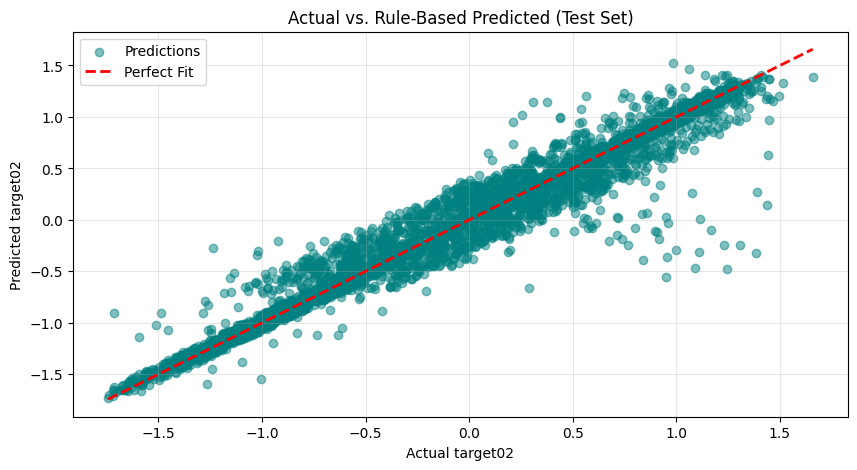

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score

def apply_new_model_tree_rules(df):
    """
    Implements the logic of the new Model Tree (Depth 3) with rounded thresholds and leaf coefficients.
    """
    preds = np.zeros(len(df))
    
    # Use .values for faster access
    f49_vals = df['feat_49'].values
    f219_vals = df['feat_219'].values
    f111_vals = df['feat_111'].values
    
    for i in range(len(df)):
        f49, f219, f111 = f49_vals[i], f219_vals[i], f111_vals[i]
        
        # --- DECISION LOGIC START (Depth 3) ---
        
        # Main split at feat_49 = 0.22
        if f49 <= 0.22:
            if f49 <= 0.17:
                if f111 <= 0.17:
                    # Leaf 5
                    preds[i] = -0.43 + (-0.15 * f49) + (-0.30 * f219) + (2.13 * f111)
                else:
                    # Leaf 6
                    preds[i] = -0.28 + (-0.07 * f49) + (-0.49 * f219) + (1.72 * f111)
            else:  # 0.17 < f49 <= 0.22
                if f111 <= 0.41:
                    # Leaf 7
                    preds[i] = 2.06 + (-12.38 * f49) + (-0.59 * f219) + (1.27 * f111)
                else:
                    # Leaf 8
                    preds[i] = 10.18 + (-53.35 * f49) + (-0.66 * f219) + (0.71 * f111)
        
        else:  # feat_49 > 0.22
            if f49 <= 0.71:
                if f49 <= 0.50:
                    # Leaf 11
                    preds[i] = -0.13 + (0.14 * f49) + (-0.94 * f219) + (-0.74 * f111)
                else:
                    # Leaf 12
                    preds[i] = 0.07 + (0.53 * f49) + (-1.20 * f219) + (0.41 * f111)
            else:  # f49 > 0.71
                if f49 <= 0.74:
                    # Leaf 13
                    preds[i] = -0.03 + (-0.06 * f49) + (1.15 * f219) + (0.34 * f111)
                else:
                    # Leaf 14
                    preds[i] = -0.04 + (-0.04 * f49) + (1.15 * f219) + (0.36 * f111)
                    
    return preds

# 1. GENERATE PREDICTIONS ON TEST DATA
# Assuming X_test and y_test are already in your environment
test_preds = apply_new_model_tree_rules(X_test)

# 2. CALCULATE METRICS
r2 = r2_score(y_test, test_preds)
mae = mean_absolute_error(y_test, test_preds)
rmse = np.sqrt(mean_squared_error(y_test, test_preds))
evs = explained_variance_score(y_test, test_preds)

# 3. OUTPUT PERFORMANCE
print("--- STANDALONE RULE PERFORMANCE (X_TEST) ---")
print(f"{'Metric':<20} | {'Value':<10}")
print("-" * 35)
print(f"{'R2 Score':<20} | {r2:>10.4f}")
print(f"{'MAE':<20} | {mae:>10.4f}")
print(f"{'RMSE':<20} | {rmse:>10.4f}")
print(f"{'Expl. Variance':<20} | {evs:>10.4f}")

# 4. VISUALIZATION
plt.figure(figsize=(10, 5))
plt.scatter(y_test, test_preds, alpha=0.5, color='teal', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.title('Actual vs. Rule-Based Predicted (Test Set)')
plt.xlabel('Actual target02')
plt.ylabel('Predicted target02')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

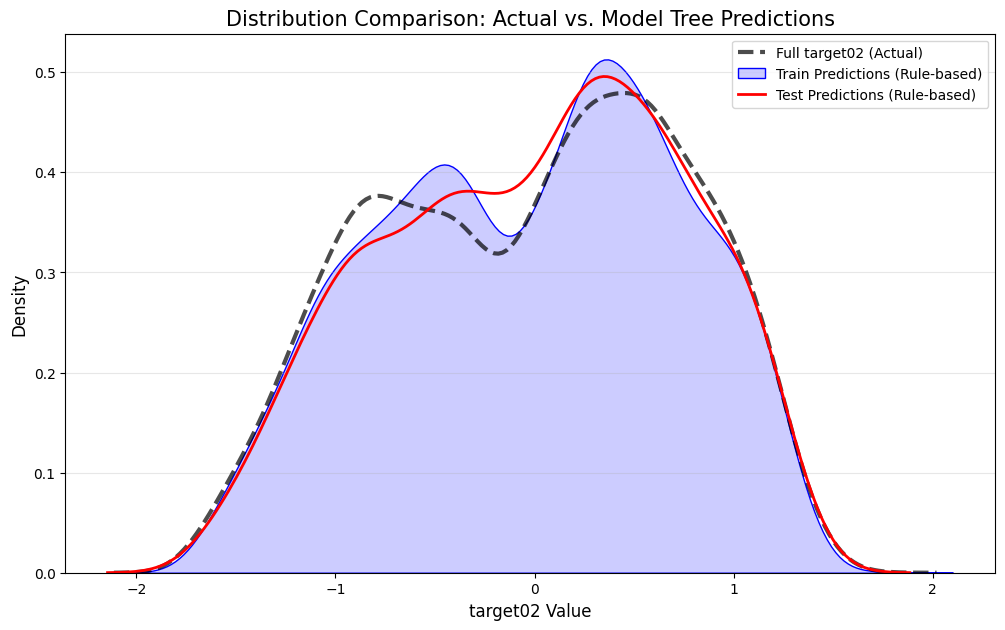

--- Distribution Statistics ---
Full Target  | Mean: -0.0189 | Std: 0.7594
Train Preds  | Mean: -0.0224 | Std: 0.7405
Test Preds   | Mean: -0.0004 | Std: 0.7325


In [152]:
import seaborn as sns

# 1. Generate predictions for the training set for comparison
train_preds = apply_new_model_tree_rules(X_train)

# 2. Setup the visualization
plt.figure(figsize=(12, 7))

# Plot Full Target Population (Ground Truth)
sns.kdeplot(y, label='Full target02 (Actual)', color='black', linewidth=3, linestyle='--', alpha=0.7)

# Plot Training Predictions
sns.kdeplot(train_preds, label='Train Predictions (Rule-based)', color='blue', fill=True, alpha=0.2)

# Plot Test Predictions
sns.kdeplot(test_preds, label='Test Predictions (Rule-based)', color='red', linewidth=2)

# Formatting
plt.title('Distribution Comparison: Actual vs. Model Tree Predictions', fontsize=15)
plt.xlabel('target02 Value', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

# Summary Statistics for Validation
print("--- Distribution Statistics ---")
print(f"Full Target  | Mean: {y.mean():.4f} | Std: {y.std():.4f}")
print(f"Train Preds  | Mean: {train_preds.mean():.4f} | Std: {train_preds.std():.4f}")
print(f"Test Preds   | Mean: {test_preds.mean():.4f} | Std: {test_preds.std():.4f}")

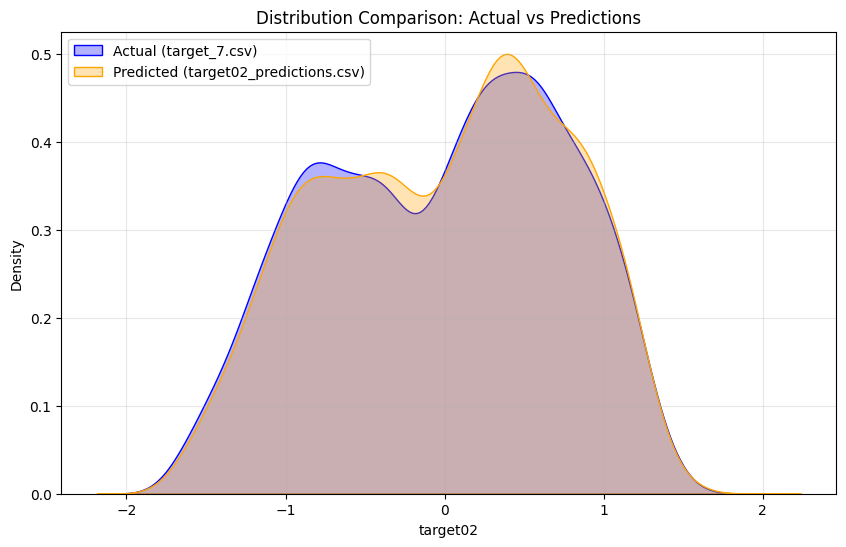

--- Distribution Statistics ---
Metric     | Actual       | Predicted   
----------------------------------------
Mean       | -0.0189      | -0.0035     
Std Dev    | 0.7594       | 0.7522      
Min        | -1.7517      | -1.8308     
Max        | 1.6582       | 1.8828      


In [30]:
import pandas as pd
import seaborn as sns


import matplotlib.pyplot as plt

# 1. Load the data
df_actual = pd.read_csv('target_7.csv')
try:
    df_pred_csv = pd.read_csv('target02_predictions.csv')
    
    # Locate the prediction column (handling case where column name might vary)
    if 'target02' in df_pred_csv.columns:
        pred_series = df_pred_csv['target02']
    else:
        # Fallback to the first column if exact name isn't found
        pred_series = df_pred_csv.iloc[:, 0]

    # 2. Visual Comparison
    plt.figure(figsize=(10, 6))
    sns.kdeplot(df_actual['target02'], label='Actual (target_7.csv)', fill=True, color='blue', alpha=0.3)
    sns.kdeplot(pred_series, label='Predicted (target02_predictions.csv)', fill=True, color='orange', alpha=0.3)
    
    plt.title('Distribution Comparison: Actual vs Predictions')
    plt.xlabel('target02')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # 3. Statistical Comparison
    print("--- Distribution Statistics ---")
    print(f"{'Metric':<10} | {'Actual':<12} | {'Predicted':<12}")
    print("-" * 40)
    print(f"{'Mean':<10} | {df_actual['target02'].mean():<12.4f} | {pred_series.mean():<12.4f}")
    print(f"{'Std Dev':<10} | {df_actual['target02'].std():<12.4f} | {pred_series.std():<12.4f}")
    print(f"{'Min':<10} | {df_actual['target02'].min():<12.4f} | {pred_series.min():<12.4f}")
    print(f"{'Max':<10} | {df_actual['target02'].max():<12.4f} | {pred_series.max():<12.4f}")

except FileNotFoundError:
    print("Error: Could not find 'target02_predictions.csv'. Ensure the file is in the directory.")

# Again but now with polinomial Regression

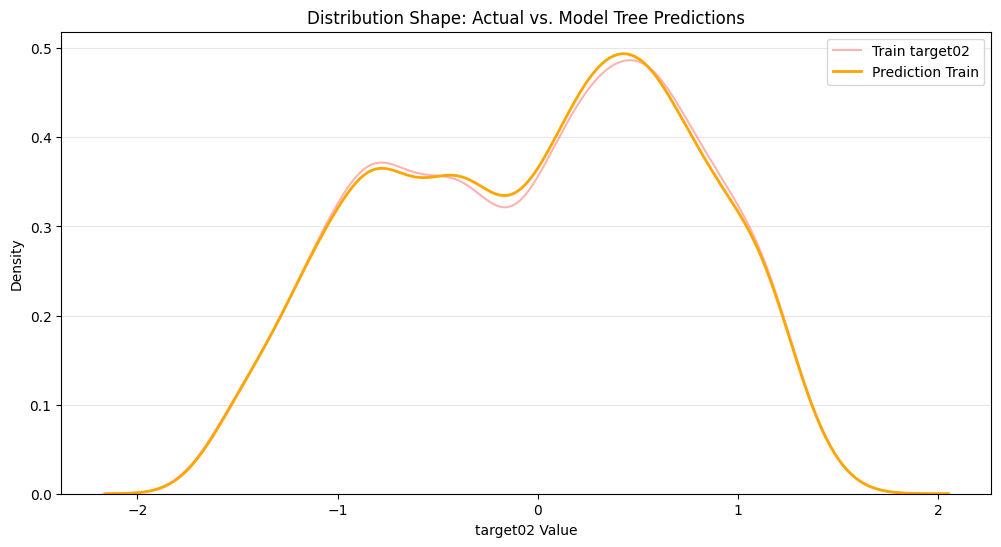

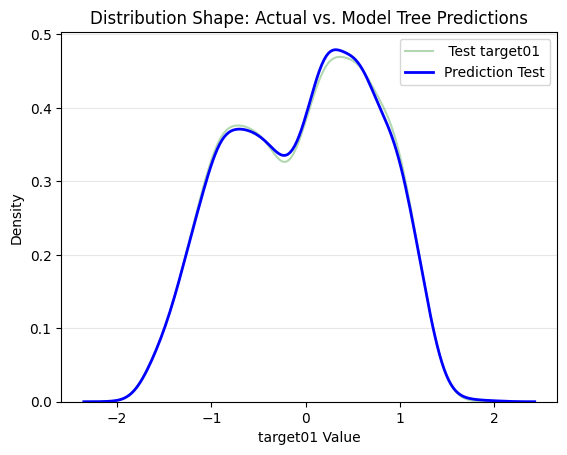

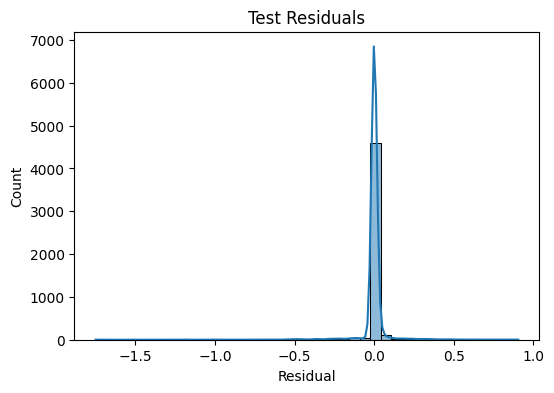

In [249]:
# Model Tree training
# feat_49     0.577335
# feat_219    0.300233
# feat_111    0.161063
# feat_64     0.026520
# feat_22     0.025823
# feat_200    0.020703
# feat_163    0.020525
# feat_240    0.017813
# feat_141    0.015871
# feat_117    0.015844
# feat_59     0.015634
# feat_132    0.014631
# feat_91     0.014069


# 1. Prepare Data
df_features = pd.read_csv('dataset_7.csv')
df_targets = pd.read_csv('target_7.csv')
top_features = ['feat_49', 'feat_219', 'feat_111','feat_22']
X = df_features[top_features]
y = df_targets['target02']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42
)


from sklearn.preprocessing import PolynomialFeatures
from lineartree import LinearTreeRegressor
from sklearn.linear_model import LinearRegression

# 1. Transform features to Degree 2 (results in 14 columns)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# 2. Initialize with a clean LinearRegression
# The model will now expect exactly 14 features based on X_train_poly
model_tree = LinearTreeRegressor(
    base_estimator=LinearRegression(),
    max_depth=3,  # Depth 3 creates 8 continuous linear regions
    min_samples_leaf=100
)
model_tree.fit(X_train_poly, y_train)
# 3.Predict



y_pred_test = model_tree.predict(X_test_poly) # Ensure you use X_test_poly here!
y_pred_train = model_tree.predict(X_train_poly)


# 4. Visualization
plt.figure(figsize=(12, 6))

# Plot actual vs predicted  Train distributions to see the "Shape"
sns.kdeplot(y_train, label='Train target02', color='red', alpha=0.3)
sns.kdeplot(y_pred_train, label='Prediction Train', color='orange', linewidth=2)

plt.title('Distribution Shape: Actual vs. Model Tree Predictions')
plt.xlabel('target02 Value')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

# Plot actual vs predicted  Test distributions to see the "Shape"
sns.kdeplot(y_test, label=' Test target01', color='green', alpha=0.3)
sns.kdeplot(y_pred_test, label='Prediction Test', color='blue', linewidth=2)


plt.title('Distribution Shape: Actual vs. Model Tree Predictions')
plt.xlabel('target01 Value')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

 ###
residuals = y_test - y_pred_test
plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Test Residuals")
plt.xlabel("Residual")
plt.show()



In [250]:
# METRIC 
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, mean_squared_error

print("TRAIN PERFORMANCE")
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("R²:", r2_score(y_train, y_pred_train))

print("\nTEST PERFORMANCE")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))
print("R²:", r2_score(y_test, y_pred_test))

TRAIN PERFORMANCE
RMSE: 0.09024577768193977
R²: 0.9860602145300715

TEST PERFORMANCE
RMSE: 0.09230986011310818
R²: 0.985023910943554


In [100]:
#RULE EXTRACTOR
# The lineartree package does not have a standalone export_text function like sklearn.
# Instead, the fitted model object has a summary() method that returns the rules.

# Build a feature name list that matches the model's training dimensionality
n_features = getattr(model_tree, 'n_features_in_', None)
feature_names_full = None

# 1) Prefer names remembered by the estimator (sklearn-style)
if hasattr(model_tree, 'feature_names_in_'):
    feature_names_full = list(model_tree.feature_names_in_)

# 2) Fall back to DataFrame columns if they match the fitted dimensionality
if feature_names_full is None:
    try:
        if isinstance(X, pd.DataFrame) and (n_features is None or X.shape[1] == n_features):
            feature_names_full = list(X.columns)
    except NameError:
        pass

# 3) If polynomial features were used, try to derive expanded names
if feature_names_full is None:
    try:
        base_cols = list(X.columns) if isinstance(X, pd.DataFrame) else [f'x{i}' for i in range(n_features or 0)]
        if 'poly' in globals():
            poly_names = poly.get_feature_names_out(base_cols)
            if n_features is None or len(poly_names) == n_features:
                feature_names_full = list(poly_names)
    except Exception:
        pass

# 4) Last resort: generic names
if feature_names_full is None:
    feature_names_full = [f'feat_{i}' for i in range(n_features or 0)]

# Use full, consistent feature names (not a subset like top_features)
tree_rules = model_tree.summary(feature_names=feature_names_full)
print(tree_rules)


def get_exact_paths(model):
    # This reaches into the underlying structure you provided in the first prompt
    tree = model.summary() 
    paths = {}

    def recurse(node_id, current_path):
        node = tree[node_id]
        if 'children' in node:
            col = node['col']
            th = node['th']
            left, right = node['children']
            # Left child is <= threshold
            recurse(left, current_path + [(col, '<=', th)])
            # Right child is > threshold
            recurse(right, current_path + [(col, '>', th)])
        else:
            paths[node_id] = current_path

    recurse(0, [])
    return paths

# Get the rules
all_rules = get_exact_paths(model_tree)

# Print them out formatted
for leaf_id, criteria in all_rules.items():
    rule_str = " AND ".join([f"{c[0]} {c[1]} {c[2]:.4f}" for c in criteria])
    print(f"Leaf {leaf_id}: {rule_str}")

# Assuming model_tree.summary() is the dictionary causing the error
summary_dict = model_tree.summary()

print("--- EXACT MODEL TREE RULES ---")

for node_id, info in summary_dict.items():
    # In the linear-tree dictionary, leaves are nodes that have a 'models' object 
    # but no 'children' (or 'models' is a single estimator, not a tuple)
    if isinstance(info.get('models'), LinearRegression):
        print(f"\nLEAF NODE: {node_id}")
        
        # 1. THE RULE (The path taken to get here)
        # Check if your dict has a 'path' or 'Rule' key. 
        # If not, the path is built from the parent splits.
        rule = info.get('path', info.get('Rule', 'Path not found in dict'))
        print(f"  RULE: {rule}")
        
        # 2. THE LINEAR EQUATION
        model = info['models']
        intercept = model.intercept_
        coefs = model.coef_
        
        equation = f"  EQUATION: y = {intercept:.6f}"
        # Align coefficient names with the full feature set used for training
        for feat, val in zip(feature_names_full, coefs):
            equation += f" + ({val:.6f} * {feat})"
        
        print(equation)
        print(f"  SAMPLES IN SEGMENT: {info.get('samples', 'N/A')}")
        print("-" * 40)

{0: {'col': 'feat_49', 'th': np.float64(0.49834), 'loss': np.float64(0.09159), 'samples': np.int64(5000), 'children': (1, 2), 'models': (LinearRegression(), LinearRegression())}, 1: {'col': 'feat_49', 'th': np.float64(0.21256), 'loss': np.float64(0.03316), 'samples': np.int64(2500), 'children': (3, 4), 'models': (LinearRegression(), LinearRegression())}, 2: {'col': 'feat_49', 'th': np.float64(0.71035), 'loss': np.float64(0.01319), 'samples': np.int64(2500), 'children': (9, 10), 'models': (LinearRegression(), LinearRegression())}, 3: {'col': 'feat_49', 'th': np.float64(0.17016), 'loss': np.float64(0.02547), 'samples': np.int64(1042), 'children': (5, 6), 'models': (LinearRegression(), LinearRegression())}, 4: {'col': 'feat_49', 'th': np.float64(0.253), 'loss': np.float64(0.0), 'samples': np.int64(1458), 'children': (7, 8), 'models': (LinearRegression(), LinearRegression())}, 9: {'col': 'feat_49', 'th': np.float64(0.66773), 'loss': np.float64(0.01362), 'samples': np.int64(1041), 'children

Actual target02: count= 10000 mean= -0.0189
Pred target02:   count= 5000 mean= -0.0168


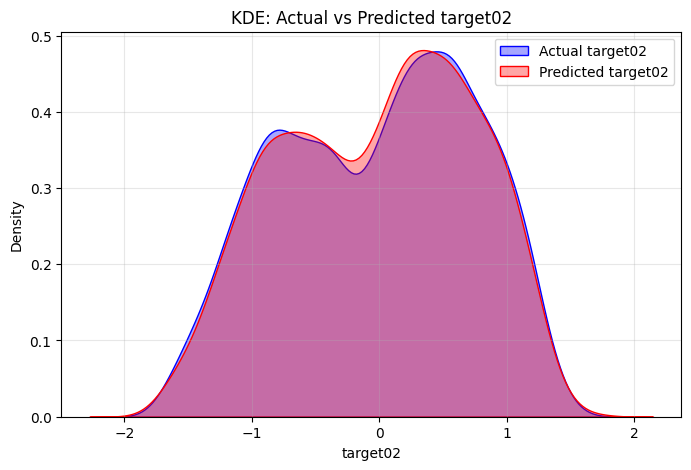

In [104]:
# KDE comparison: target02 actual vs predicted
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Load data
actual_df = pd.read_csv('target_7.csv')
pred_df = pd.read_csv('target02_predictions.csv')

# Select columns (handles common naming variants)
actual_col = 'target02'
pred_col_candidates = ['target02', 'target02_pred', 'target02_prediction']

pred_col = None
for col in pred_col_candidates:
    if col in pred_df.columns:
        pred_col = col
        break

if pred_col is None:
    raise ValueError("Could not find a target02 column in target02_predictions.csv")

actual_series = actual_df[actual_col]
pred_series = pred_df[pred_col]

# Basic stats for quick sanity check
print("Actual target02: count=", actual_series.shape[0], "mean=", round(actual_series.mean(), 4))
print("Pred target02:   count=", pred_series.shape[0], "mean=", round(pred_series.mean(), 4))

# KDE plot
plt.figure(figsize=(8, 5))
sns.kdeplot(actual_series, label='Actual target02', color='blue', fill=True, alpha=0.35)
sns.kdeplot(pred_series, label='Predicted target02', color='red', fill=True, alpha=0.35)
plt.title('KDE: Actual vs Predicted target02')
plt.xlabel('target02')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Calculate metrics
# r2 = r2_score(actual_series, pred_series)
# mae = mean_absolute_error(actual_series, pred_series)
# rmse = np.sqrt(mean_squared_error(actual_series, pred_series))

# print("\n" + "="*50)
# print("PERFORMANCE METRICS")
# print("="*50)
# print(f"R² Score:  {r2:.6f}")
# print(f"MAE:       {mae:.6f}")
# print(f"RMSE:      {rmse:.6f}")
# print("="*50)

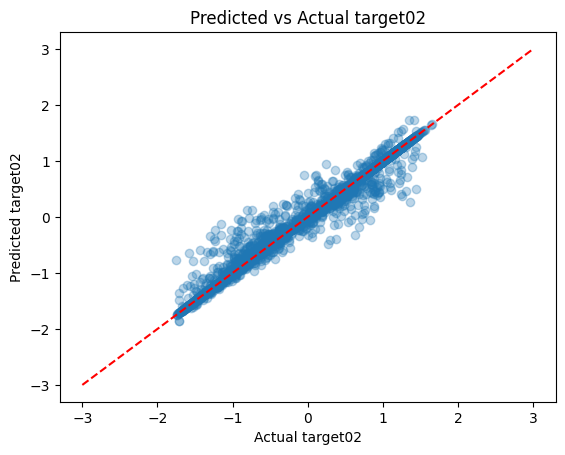

In [54]:
#Scatter Plot
plt.scatter(actual_series, pred_series, alpha=0.3)
plt.xlabel('Actual target02')
plt.ylabel('Predicted target02')
plt.title('Predicted vs Actual target02')
plt.plot([-3, 3], [-3, 3], color='red', linestyle='--')  # diagonal line
plt.show()


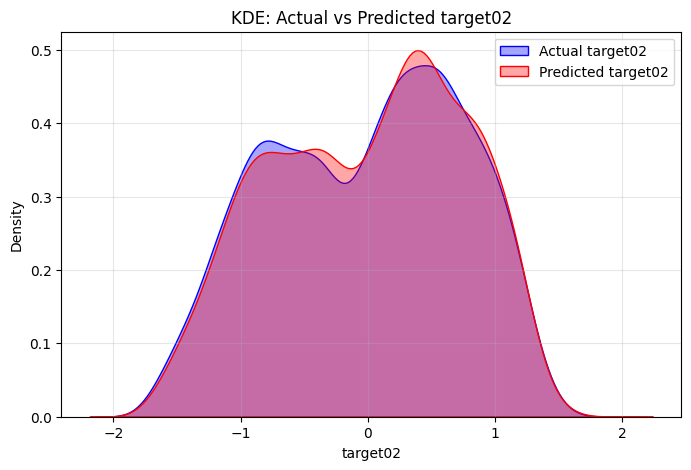

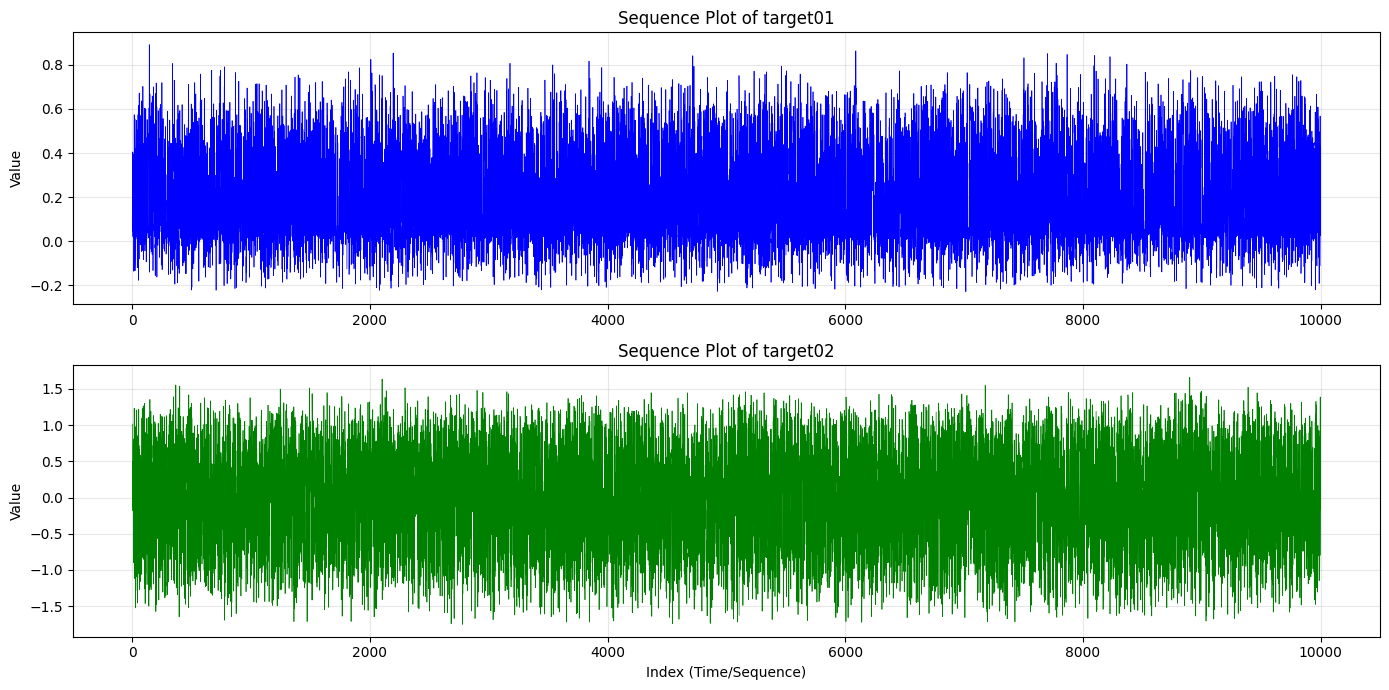

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('target_7.csv')

# Plotting the raw sequence
plt.figure(figsize=(14, 7))

# Plot target01
plt.subplot(2, 1, 1)
plt.plot(df['target01'], color='blue', linewidth=0.5)
plt.title('Sequence Plot of target01')
plt.ylabel('Value')
plt.grid(True, alpha=0.3)

# Plot target02
plt.subplot(2, 1, 2)
plt.plot(df['target02'], color='green', linewidth=0.5)
plt.title('Sequence Plot of target02')
plt.xlabel('Index (Time/Sequence)')
plt.ylabel('Value')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#Testing framwork on Test Split

FRAMEWORK PREDICTIONS - TEST SET EVALUATION
R² Score:  0.988622
MAE:       0.018127
RMSE:      0.080462


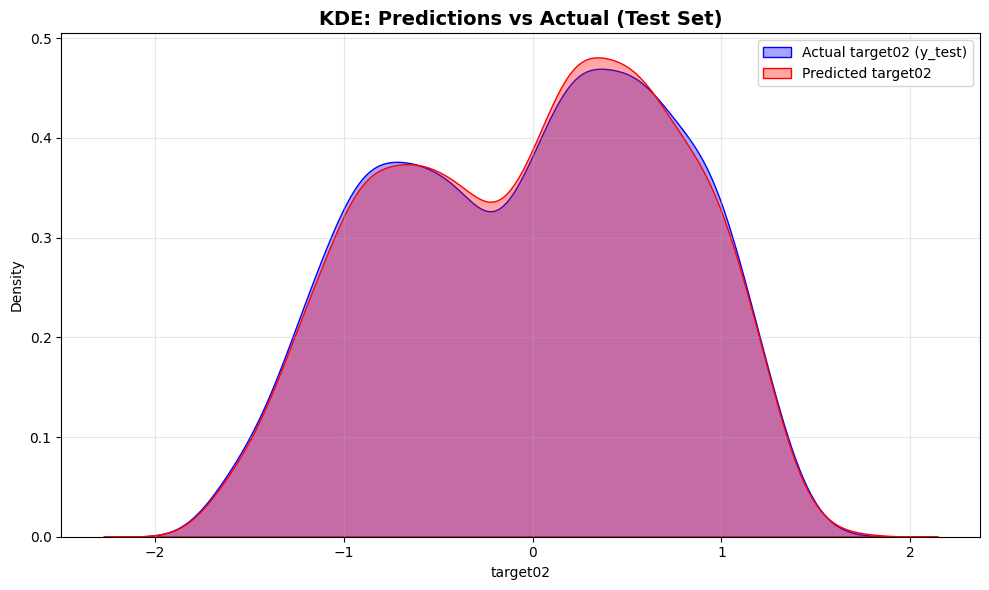


Predictions saved to 'target02_predictions.csv'


In [105]:
import argparse
import numpy as np
import pandas as pd
import operator 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

def framework(pairs, arr):
    """
    Args:
       - pairs:  a list of (cond, calc) tuples. calc() must be an executable
       - arr: a numpy array with the features in order feat_1, feat_2, ...
    
    Executes the first calc() whose cond returns True.
    Returns None if no condition matches.
    """
    targets = []

    for i in range(arr.shape[0]):
        row = arr[i]
        for cond, calc in pairs:
            if cond_eval(cond, row):
                targets.append(calc(row))
                break
        
    return targets


def cond_eval(condition, arr):
    """evaluate a condition
        - condition: must be a tupe of (int, string, float). The second entry must be a string from the list below, describing the operator. Third entry of the tuple must be a float). If condition is None, it is always evaluated to true.
        - arr: array on which the condition is evaluated

    The python operator package is used. Second entry in condition must be one of those:
       ops = {
         ">": operator.gt,
        ">=": operator.ge,
        "<": operator.lt,
        "<=": operator.le,
        "==": operator.eq,
        "!=": operator.ne,
    }
    """
    ops = {
         ">": operator.gt,
        ">=": operator.ge,
        "<": operator.lt,
        "<=": operator.le,
        "==": operator.eq,
        "!=": operator.ne,
    }

    if condition is None:
        return True
    
    op = ops[condition[1]]
    return op(arr[condition[0]], condition[2])


def main(args):

    # Load data (feat_22=idx 22, feat_49=idx 49, feat_111=idx 111, feat_219=idx 219)
    # Modified to accept DataFrame directly instead of file path
    data_array = args.values

    # 1. Define Calculations (Polynomial Equations)

    def calc_1(r): 
        return (-0.45 * r[1]) + (1.75 * r[2]) + (-0.65 * r[3])

    def calc_2(r): 
        return (-51.95 + (544.10 * r[0]) + (1.86 * r[1]) + (14.76 * r[2]) + (-2.67 * r[3]) + 
                (-1418.28 * r[0]**2) + (-14.08 * r[0] * r[1]) + (-70.67 * r[0] * r[2]) + 
                (11.08 * r[0] * r[3]) + (0.23 * r[1]**2) + (-0.34 * r[1] * r[2]) + 
                (0.26 * r[1] * r[3]) + (0.06 * r[2]**2) + (-0.27 * r[2] * r[3]) + (0.07 * r[3]**2))

    def calc_3(r): 
        return (-0.95 * r[1]) + (-0.75 * r[2]) + (-0.15 * r[3])

    def calc_4(r): 
        return (152.89 + (-637.30 * r[0]) + (-3.28 * r[1]) + (-4.60 * r[2]) + (2.04 * r[3]) + 
                (663.22 * r[0]**2) + (5.08 * r[0] * r[1]) + (8.74 * r[0] * r[2]) + 
                (-4.14 * r[0] * r[3]) + (-0.02 * r[1]**2) + (-0.14 * r[1] * r[2]) + 
                (-0.02 * r[1] * r[3]) + (-0.08 * r[2]**2) + (-0.29 * r[2] * r[3]) + (-0.07 * r[3]**2))

    def calc_5(r): 
        return (-1.25 * r[1]) + (0.45 * r[2]) + (0.75 * r[3])

    def calc_6(r): 
        return (499.29 + (-1457.31 * r[0]) + (-32.97 * r[1]) + (3.36 * r[2]) + (12.42 * r[3]) + 
                (1062.88 * r[0]**2) + (47.23 * r[0] * r[1]) + (-4.07 * r[0] * r[2]) + 
                (-16.99 * r[0] * r[3]) + (-0.21 * r[1]**2) + (0.14 * r[1] * r[2]) + 
                (-0.30 * r[1] * r[3]) + (-0.18 * r[2]**2) + (-0.13 * r[2] * r[3]) + (0.03 * r[3]**2))

    def calc_7(r): 
        return (1.15 * r[1]) + (0.35 * r[2]) + (-0.15 * r[3])

    def calc_8(r): 
        return (1.15 * r[1]) + (0.35 * r[2]) + (-0.15 * r[3])

    # 2. Define Sequential Pair List
    # The framework executes the FIRST match. The logic follows the feat_49 splits.
    # Note: Using index 0 for feat_49 since it's the first column in X_test
    pair_list = [
        ((0, "<=", 0.17), calc_1),   # 0.1701
        ((0, "<=", 0.21), calc_2),   # 0.2147
        ((0, "<=", 0.46), calc_3),   # 0.4615
        ((0, "<=", 0.50), calc_4),   # 0.5023 (End of Left Tree)
        ((0, "<=", 0.67), calc_5),  # 0.6653
        ((0, "<=", 0.71), calc_6),  # 0.7059
        ((0, "<=", 0.74), calc_7),  # 0.7438
        (None, calc_8)               # Else (> 0.7438)
    ]
    
    return framework(pair_list, data_array)


def main_example(args):

    # Example: 
    test_arr = np.ones((10,10))

    def calc1(arr):
        """square first array column"""
        return arr[0]**2

    def calc2(arr):
        """add columns 3 and 4"""
        return arr[2] + arr[3]

    condition1 = (0,">=", 0.5)
    condition2 = (8, "==", 0.0)

    predict_targets = framework([(condition1, calc1), (condition2, calc2)], test_arr)
    print (predict_targets)


if __name__ == "__main__":
    # 1. Prepare Data
    df_features = pd.read_csv('dataset_7.csv')
    df_targets = pd.read_csv('target_7.csv')
    # Features in order: feat_49, feat_219, feat_111, feat_22
    # Mapping: r[0]=feat_49, r[1]=feat_219, r[2]=feat_111, r[3]=feat_22
    top_features = ['feat_49', 'feat_219', 'feat_111','feat_22']
    X = df_features[top_features]
    y = df_targets['target02']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.5, random_state=42
    )
    args = X_test

    # Get predictions using framework
    target02_predictions = main(args)
    
    # Convert to array for metrics calculation
    predictions_array = np.array(target02_predictions)
    
    # Calculate metrics
    r2 = r2_score(y_test, predictions_array)
    mae = mean_absolute_error(y_test, predictions_array)
    rmse = np.sqrt(mean_squared_error(y_test, predictions_array))
    
    print("="*60)
    print("FRAMEWORK PREDICTIONS - TEST SET EVALUATION")
    print("="*60)
    print(f"R² Score:  {r2:.6f}")
    print(f"MAE:       {mae:.6f}")
    print(f"RMSE:      {rmse:.6f}")
    print("="*60)
    
    # Distribution plot (KDE)
    plt.figure(figsize=(10, 6))
    sns.kdeplot(y_test, label='Actual target02 (y_test)', color='blue', fill=True, alpha=0.35)
    sns.kdeplot(predictions_array, label='Predicted target02', color='red', fill=True, alpha=0.35)
    plt.title('KDE: Predictions vs Actual (Test Set)', fontsize=14, fontweight='bold')
    plt.xlabel('target02')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Save predictions
    pd.DataFrame({"target02": target02_predictions}).to_csv("target02_predictions.csv", index=False)
    print("\nPredictions saved to 'target02_predictions.csv'")